<a href="https://www.kaggle.com/code/lalit7881/global-nuclear-energy-intelligence-eda?scriptVersionId=324384071" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchana1990/global-nuclear-energy-intelligence/global_nuclear_energy_intelligence_1965_2025.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/global-nuclear-energy-intelligence/global_nuclear_energy_intelligence_1965_2025.csv")

In [3]:
df.head()

,country,iso_code,year,population,gdp,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption,nuclear_elec_per_capita,...,nuclear_dependency_tier,decarbonisation_score,is_low_carbon_majority,nuclear_vs_renewables_twh,renewables_overtook_nuclear,carbon_intensity_tier,last_nuclear_year,is_phase_out_country,decade,energy_mix_diversity
0,ASEAN (Ember),NaN,2000,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,19.33,0,-73.23,0,High,NaN,0,2000,3
1,ASEAN (Ember),NaN,2001,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,19.06,0,-77.19,0,High,NaN,0,2000,3
2,ASEAN (Ember),NaN,2002,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,17.67,0,-76.53,0,High,NaN,0,2000,3
3,ASEAN (Ember),NaN,2003,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,16.67,0,-76.39,0,High,NaN,0,2000,3
4,ASEAN (Ember),NaN,2004,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,15.70,0,-77.95,0,High,NaN,0,2000,3


In [4]:
df.tail()

,country,iso_code,year,population,gdp,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption,nuclear_elec_per_capita,...,nuclear_dependency_tier,decarbonisation_score,is_low_carbon_majority,nuclear_vs_renewables_twh,renewables_overtook_nuclear,carbon_intensity_tier,last_nuclear_year,is_phase_out_country,decade,energy_mix_diversity
15040,Zimbabwe,ZWE,2020,15526887.0,2.317871e+10,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,58.57,1,-3.93,0,Medium,NaN,0,2020,3
15041,Zimbabwe,ZWE,2021,15797220.0,2.514009e+10,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,70.71,1,-6.06,0,Low,NaN,0,2020,3
15042,Zimbabwe,ZWE,2022,16069061.0,2.590159e+10,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,67.34,1,-6.02,0,Low,NaN,0,2020,3
15043,Zimbabwe,ZWE,2023,16340829.0,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,56.16,1,-5.61,0,Medium,NaN,0,2020,3
15044,Zimbabwe,ZWE,2024,16634366.0,NaN,0.0,0.0,0.0,0.0,0.0,...,Nuclear-Free,57.12,1,-5.86,0,Medium,NaN,0,2020,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15045 entries, 0 to 15044
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      15045 non-null  object 
 1   iso_code                     11285 non-null  object 
 2   year                         15045 non-null  int64  
 3   population                   11412 non-null  float64
 4   gdp                          8397 non-null   float64
 5   nuclear_electricity          15045 non-null  float64
 6   nuclear_share_elec           15045 non-null  float64
 7   nuclear_share_energy         15045 non-null  float64
 8   nuclear_consumption          15045 non-null  float64
 9   nuclear_elec_per_capita      15045 non-null  float64
 10  nuclear_energy_per_capita    15045 non-null  float64
 11  nuclear_cons_change_pct      2080 non-null   float64
 12  nuclear_cons_change_twh      7068 non-null   float64
 13  renewables_elect

In [6]:
df.describe()

,year,population,gdp,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption,nuclear_elec_per_capita,nuclear_energy_per_capita,nuclear_cons_change_pct,...,nuclear_share_yoy_change,nuclear_share_5yr_mean,decarbonisation_score,is_low_carbon_majority,nuclear_vs_renewables_twh,renewables_overtook_nuclear,last_nuclear_year,is_phase_out_country,decade,energy_mix_diversity
count,15045.000000,1.141200e+04,8.397000e+03,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000,2080.000000,...,14742.000000,14439.000000,15045.000000,15045.000000,15045.000000,15045.000000,3015.000000,15045.000000,15045.000000,15045.000000
mean,1997.984048,3.289811e+07,4.039516e+11,40.798401,2.695917,1.082886,62.547906,172.235281,448.162996,36.696004,...,0.044825,2.680103,17.613625,0.157195,-26.640879,0.095513,2022.009950,0.018943,1993.585244,1.510867
std,16.167764,1.214852e+08,1.439329e+12,219.048425,9.578615,4.079824,381.851738,748.916602,1985.807282,362.116214,...,1.712769,9.460163,28.759844,0.363997,226.786748,0.293933,9.847876,0.136329,16.559281,1.953451
min,1965.000000,1.776000e+03,1.642060e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,...,-74.112000,0.000000,0.000000,0.000000,-6517.060000,0.000000,1976.000000,0.000000,1960.000000,0.000000
25%,1985.000000,7.568235e+05,1.596272e+10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.886750,...,0.000000,0.000000,0.000000,0.000000,-3.760000,0.000000,2024.000000,0.000000,1980.000000,0.000000
50%,1999.000000,5.899260e+06,5.671950e+10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.892500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025.000000,0.000000,1990.000000,1.000000
75%,2012.000000,1.991802e+07,2.311147e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.793500,...,0.000000,0.000000,28.500000,0.000000,0.000000,0.000000,2025.000000,0.000000,2010.000000,3.000000
max,2025.000000,1.463866e+09,2.696602e+13,2644.740000,88.011000,41.661000,6391.846000,8908.020000,24744.818000,11200.001000,...,65.057000,84.760000,100.000000,1.000000,950.220000,1.000000,2025.000000,1.000000,2020.000000,6.000000


In [7]:
df.isnull()

,country,iso_code,year,population,gdp,nuclear_electricity,nuclear_share_elec,nuclear_share_energy,nuclear_consumption,nuclear_elec_per_capita,...,nuclear_dependency_tier,decarbonisation_score,is_low_carbon_majority,nuclear_vs_renewables_twh,renewables_overtook_nuclear,carbon_intensity_tier,last_nuclear_year,is_phase_out_country,decade,energy_mix_diversity
0,False,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
15041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
15042,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
15043,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [8]:
df.isnull().sum()

country                            0
iso_code                        3760
year                               0
population                      3633
gdp                             6648
nuclear_electricity                0
nuclear_share_elec                 0
nuclear_share_energy               0
nuclear_consumption                0
nuclear_elec_per_capita            0
nuclear_energy_per_capita          0
nuclear_cons_change_pct        12965
nuclear_cons_change_twh         7977
renewables_electricity          5939
renewables_share_elec              0
solar_electricity               5957
wind_electricity                6161
hydro_electricity               6034
solar_share_elec                7603
wind_share_elec                 7807
fossil_electricity              8204
fossil_share_elec               8230
coal_electricity                8289
gas_electricity                 8387
coal_share_elec                 8315
gas_share_elec                  8413
carbon_intensity_elec              0
g

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

country                         object
iso_code                        object
year                             int64
population                     float64
gdp                            float64
nuclear_electricity            float64
nuclear_share_elec             float64
nuclear_share_energy           float64
nuclear_consumption            float64
nuclear_elec_per_capita        float64
nuclear_energy_per_capita      float64
nuclear_cons_change_pct        float64
nuclear_cons_change_twh        float64
renewables_electricity         float64
renewables_share_elec          float64
solar_electricity              float64
wind_electricity               float64
hydro_electricity              float64
solar_share_elec               float64
wind_share_elec                float64
fossil_electricity             float64
fossil_share_elec              float64
coal_electricity               float64
gas_electricity                float64
coal_share_elec                float64
gas_share_elec           

In [11]:
df.shape

(15045, 54)

In [12]:
df.columns

Index(['country', 'iso_code', 'year', 'population', 'gdp',
       'nuclear_electricity', 'nuclear_share_elec', 'nuclear_share_energy',
       'nuclear_consumption', 'nuclear_elec_per_capita',
       'nuclear_energy_per_capita', 'nuclear_cons_change_pct',
       'nuclear_cons_change_twh', 'renewables_electricity',
       'renewables_share_elec', 'solar_electricity', 'wind_electricity',
       'hydro_electricity', 'solar_share_elec', 'wind_share_elec',
       'fossil_electricity', 'fossil_share_elec', 'coal_electricity',
       'gas_electricity', 'coal_share_elec', 'gas_share_elec',
       'carbon_intensity_elec', 'greenhouse_gas_emissions',
       'low_carbon_electricity', 'low_carbon_share_elec', 'energy_per_gdp',
       'primary_energy_consumption', 'ever_had_nuclear', 'is_nuclear_active',
       'gdp_per_capita_usd', 'urban_pop_pct', 'energy_use_per_capita',
       'wb_nuclear_share_elec_pct', 'wb_population', 'wb_gdp_usd',
       'co2_mtonne', 'co2_per_capita_t', 'nuclear_share_yoy_

In [13]:
df.nunique()

country                          303
iso_code                         220
year                              61
population                     11393
gdp                             8397
nuclear_electricity             2145
nuclear_share_elec              1802
nuclear_share_energy            1926
nuclear_consumption             2004
nuclear_elec_per_capita         1647
nuclear_energy_per_capita       1595
nuclear_cons_change_pct         1946
nuclear_cons_change_twh         1916
renewables_electricity          4779
renewables_share_elec           6025
solar_electricity               1007
wind_electricity                1353
hydro_electricity               4478
solar_share_elec                1690
wind_share_elec                 1964
fossil_electricity              3725
fossil_share_elec               4983
coal_electricity                2643
gas_electricity                 3025
coal_share_elec                 3290
gas_share_elec                  3877
carbon_intensity_elec           4948
g

## EDA

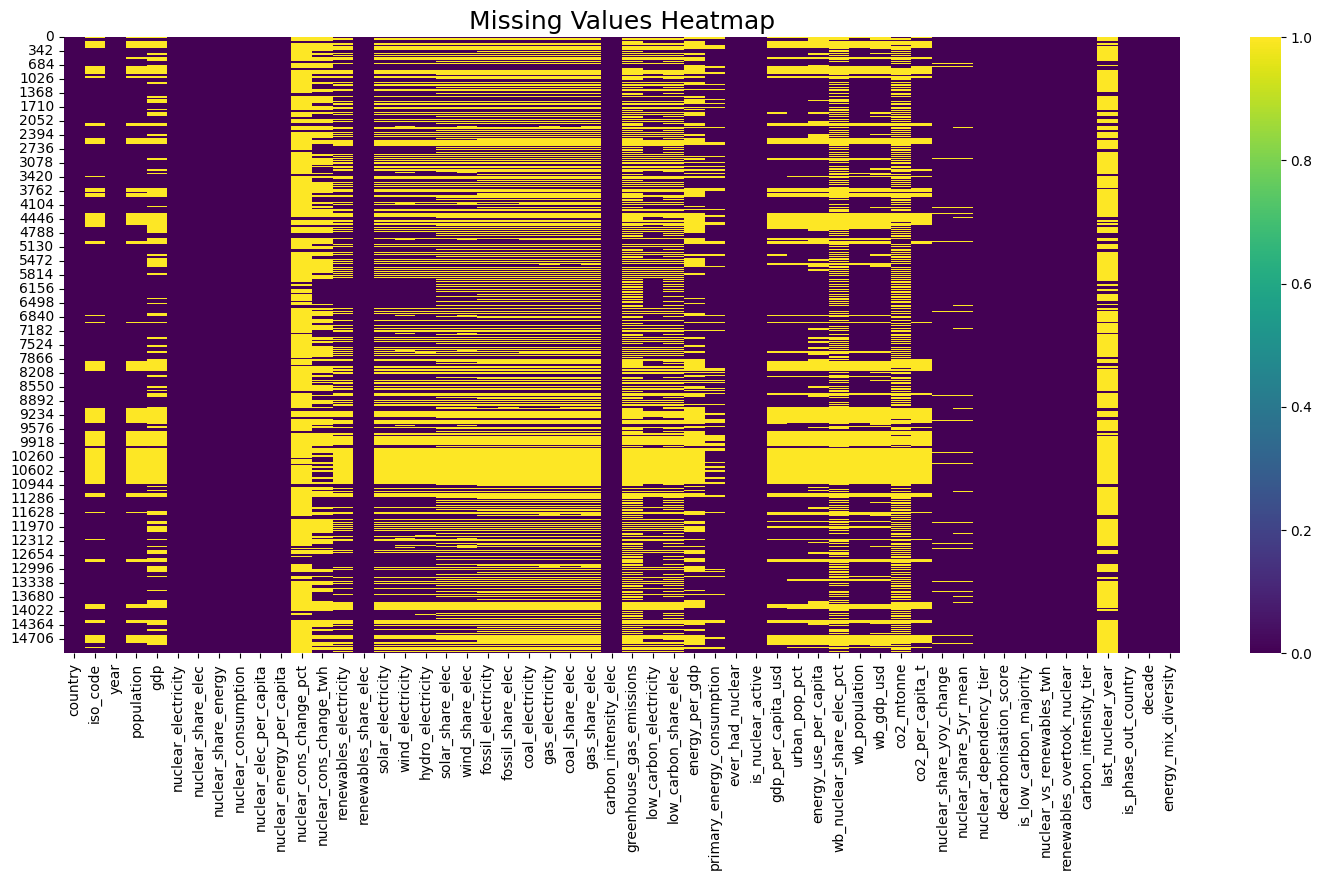

In [14]:
plt.figure(figsize=(18,8))
sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='viridis'
)
plt.title("Missing Values Heatmap", fontsize=18)
plt.show()

In [15]:
numerical_cols = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object','category']
).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 50
Categorical Columns: 4


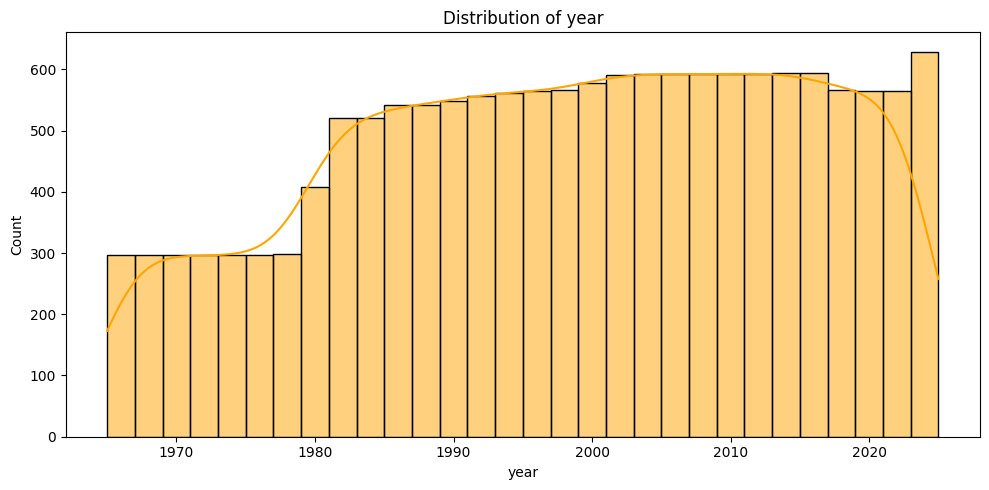

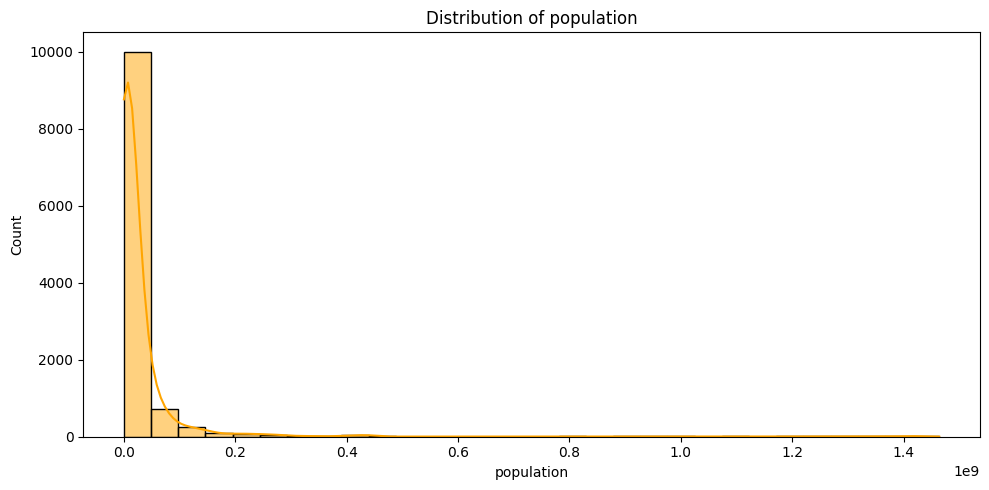

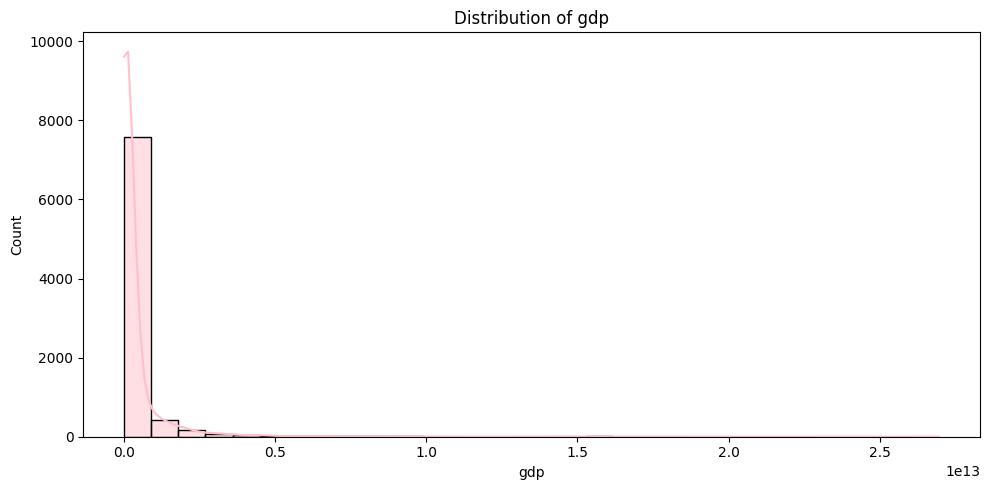

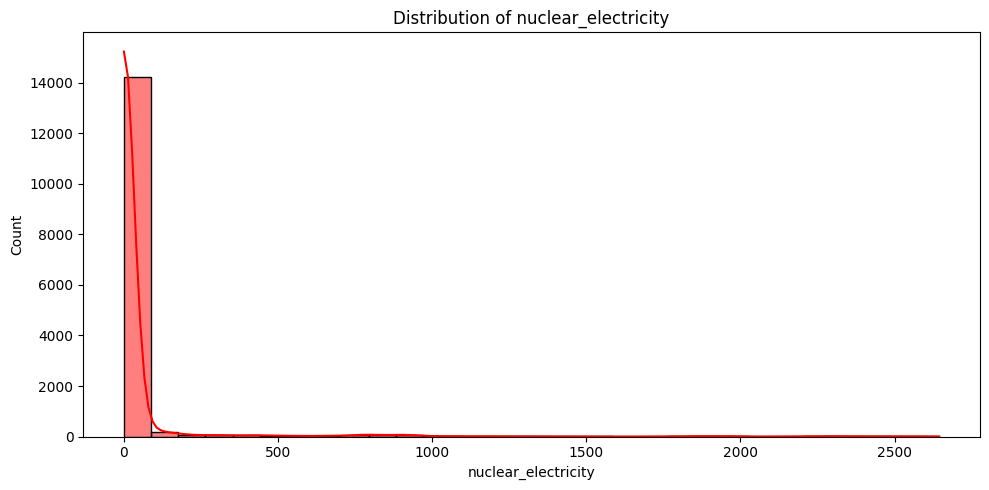

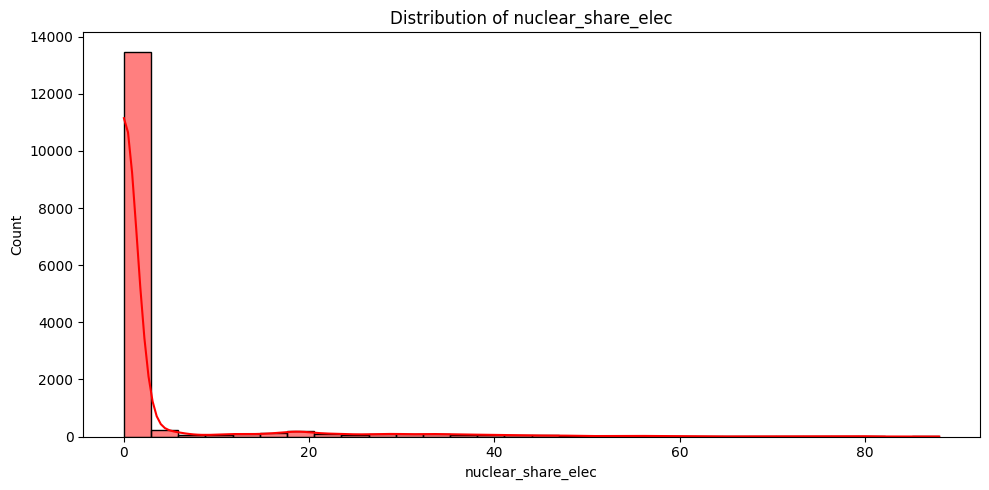

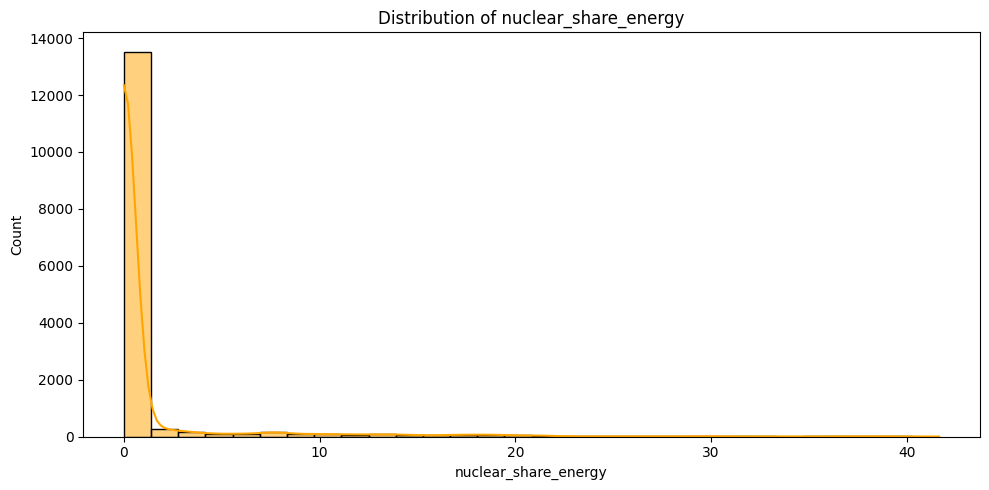

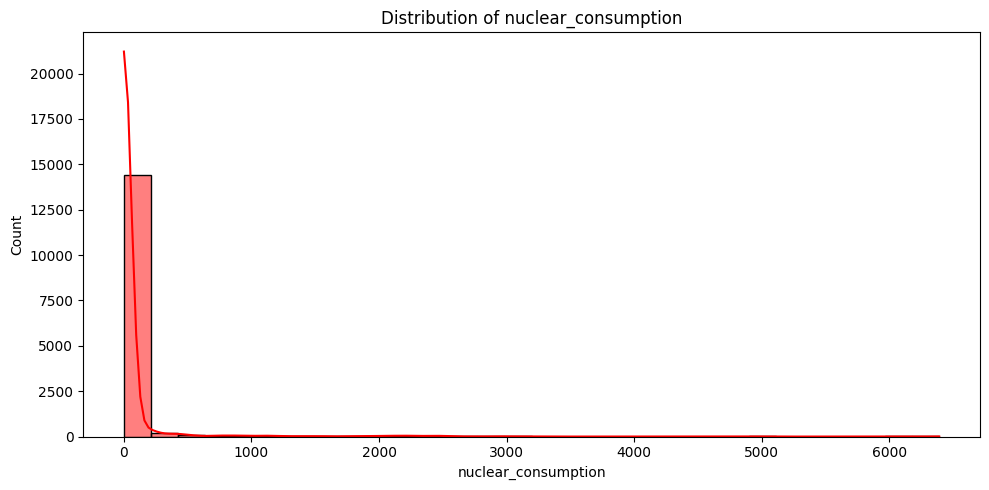

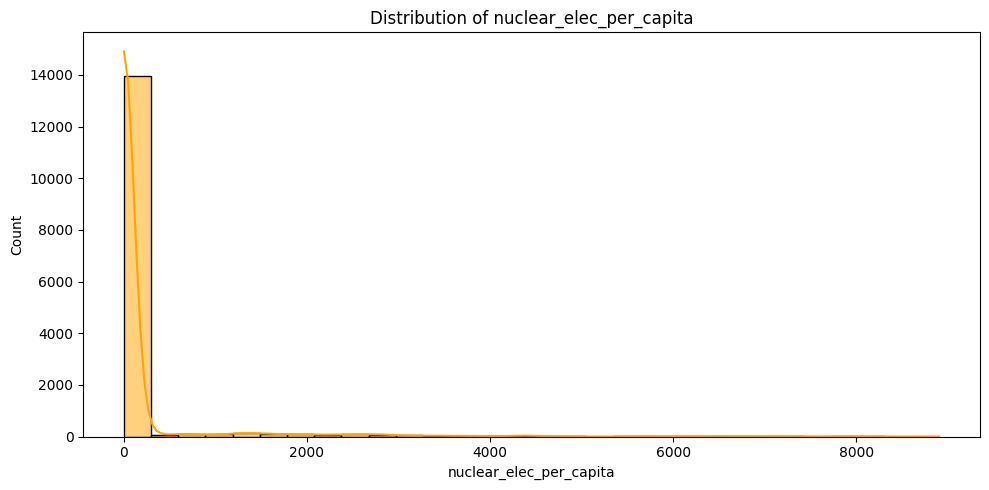

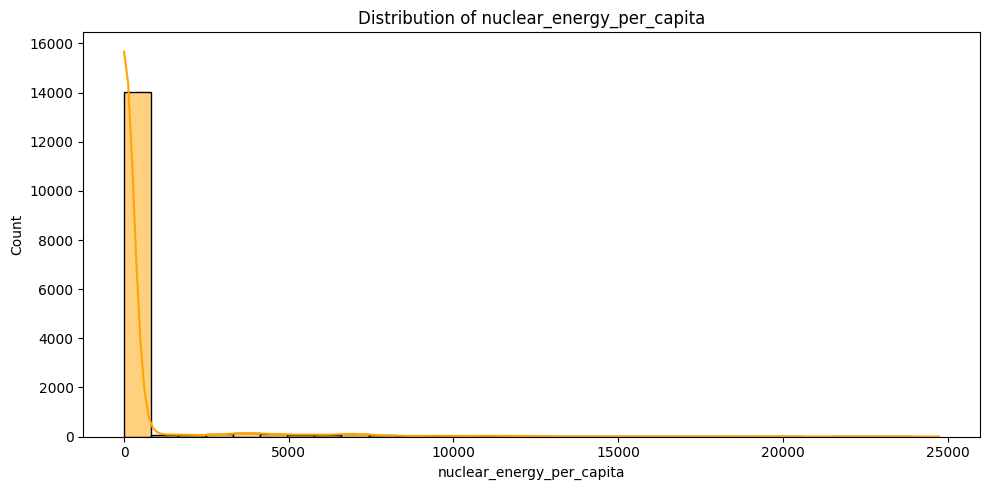

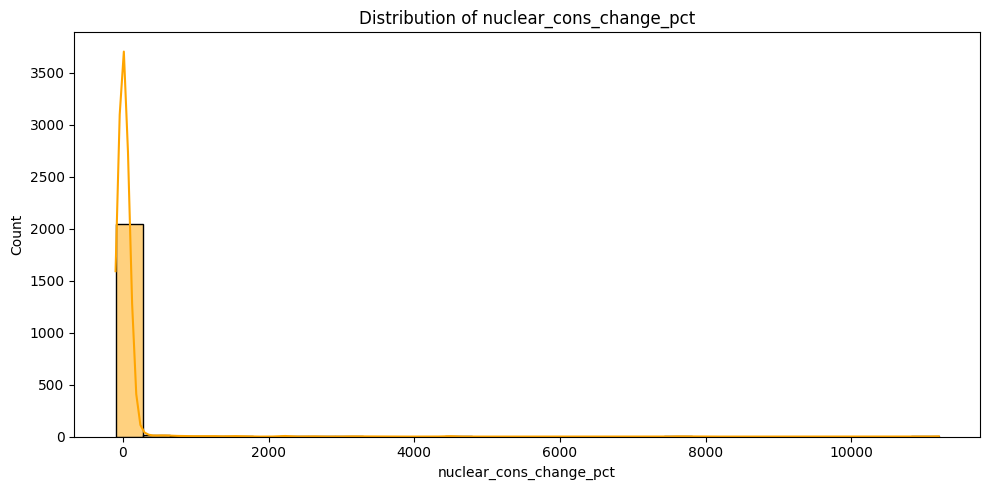

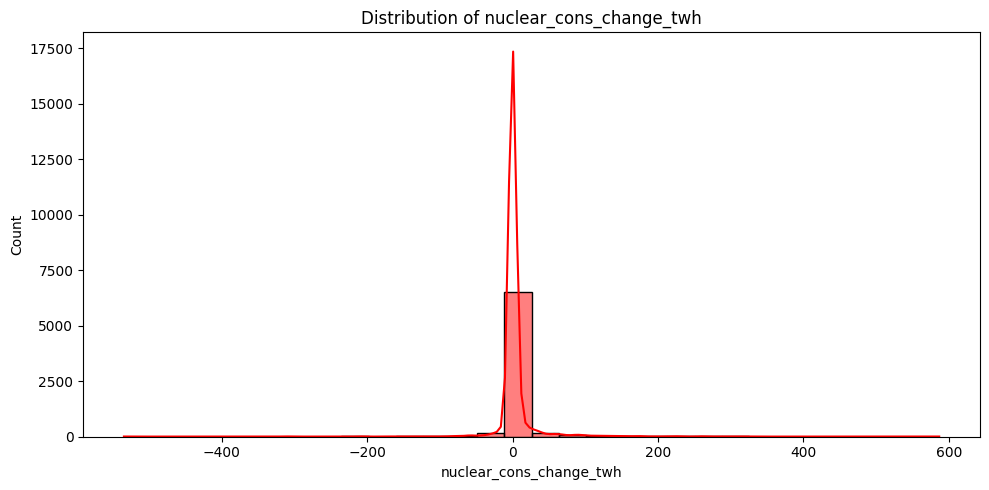

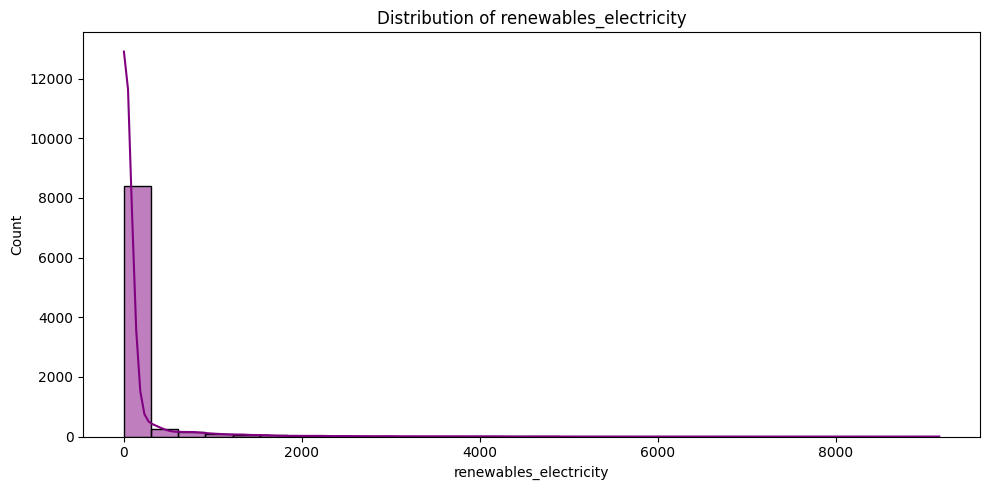

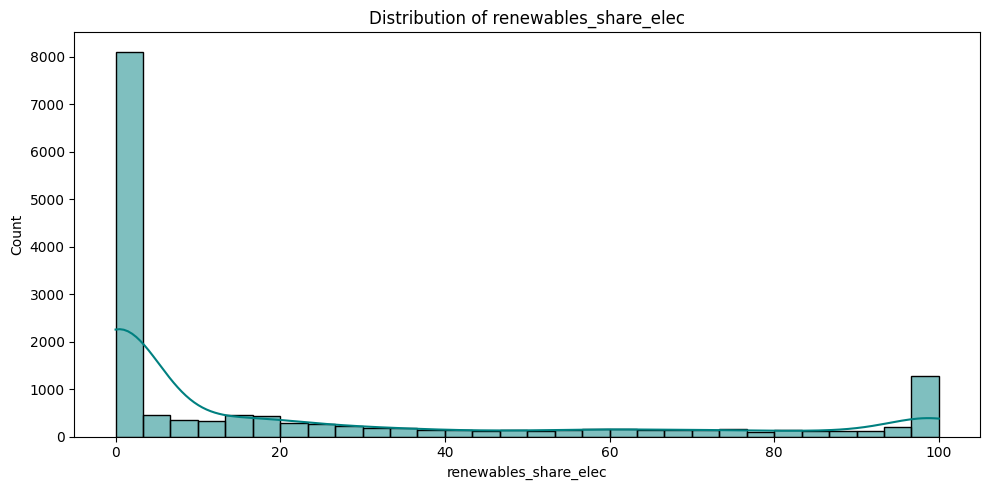

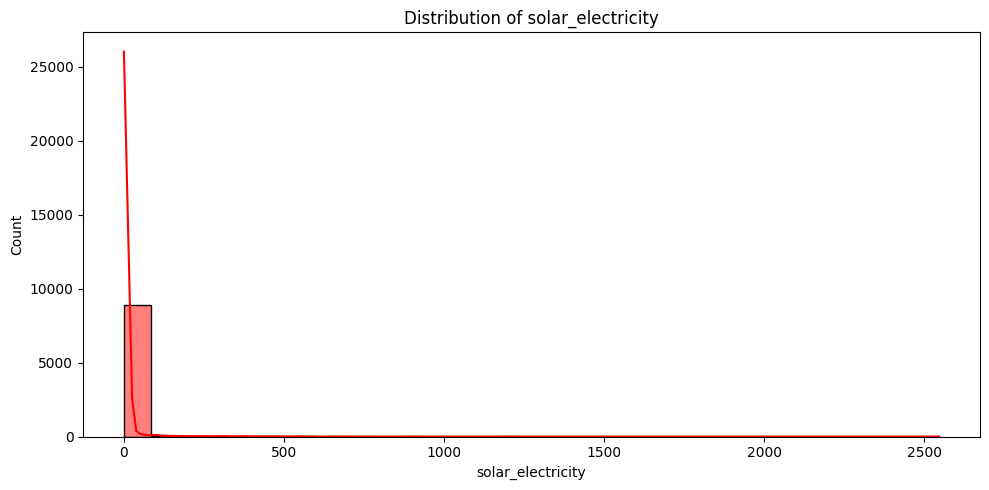

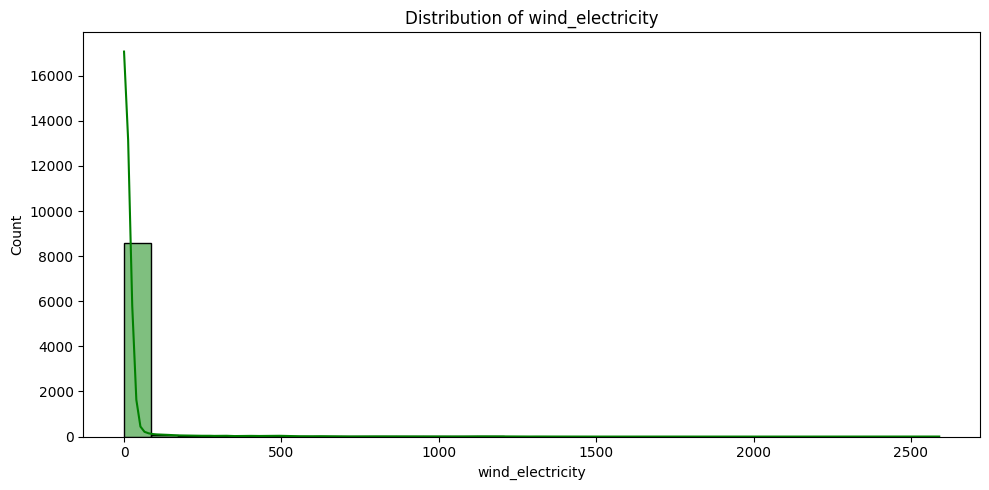

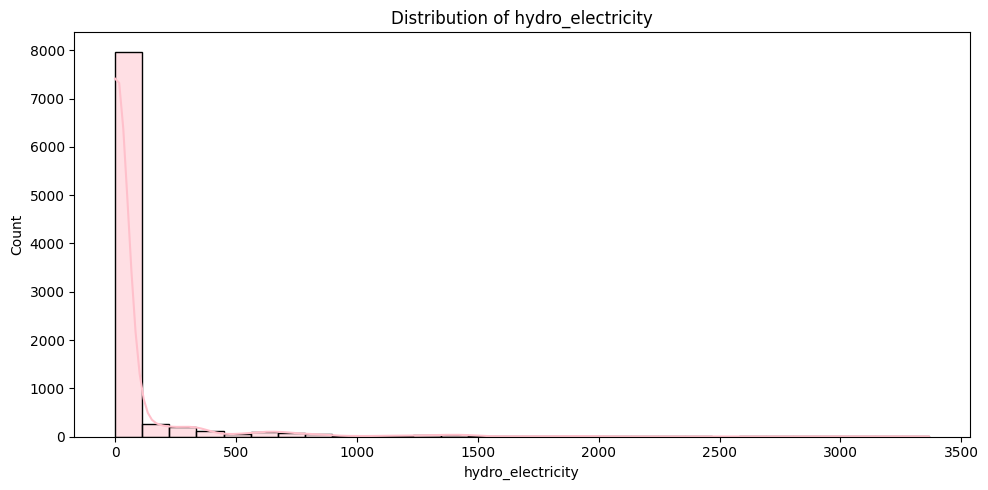

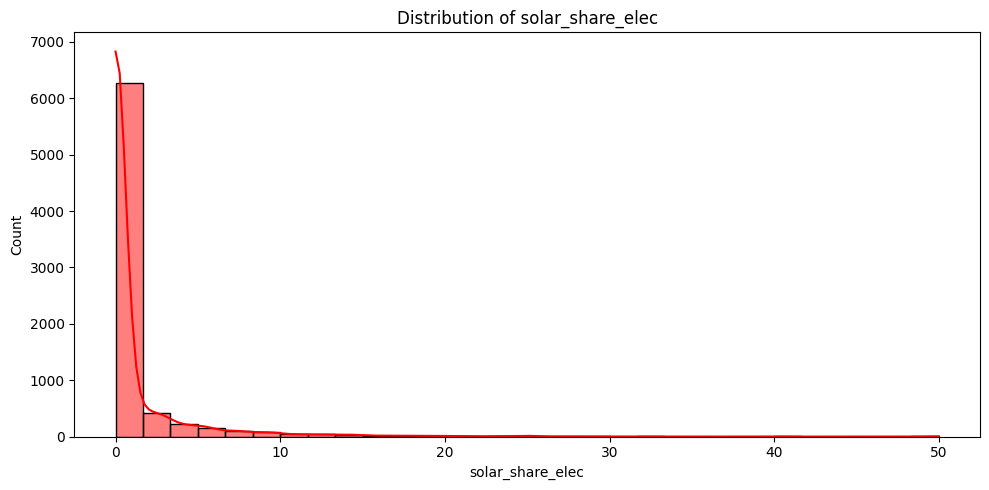

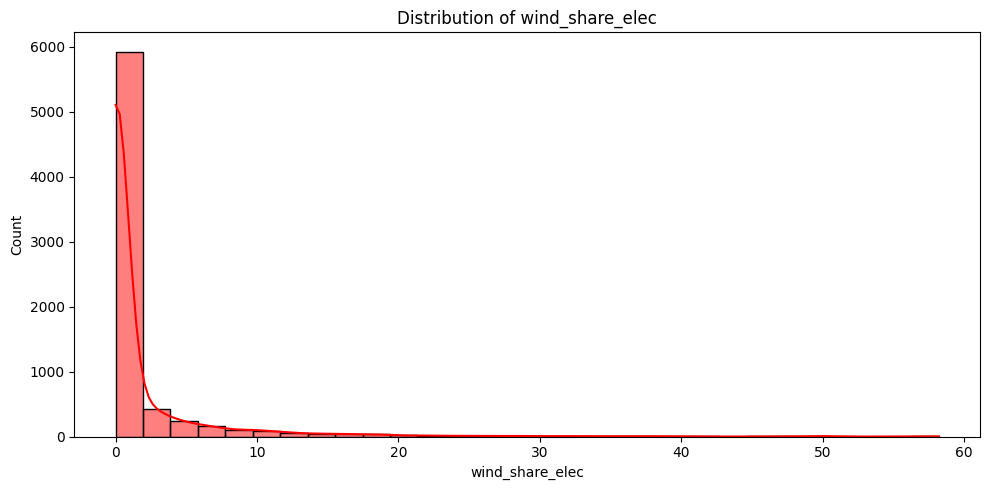

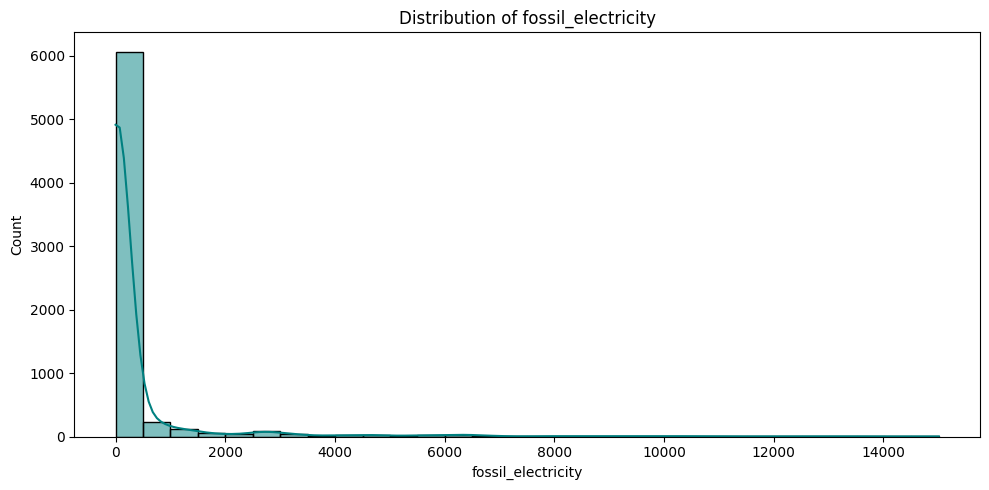

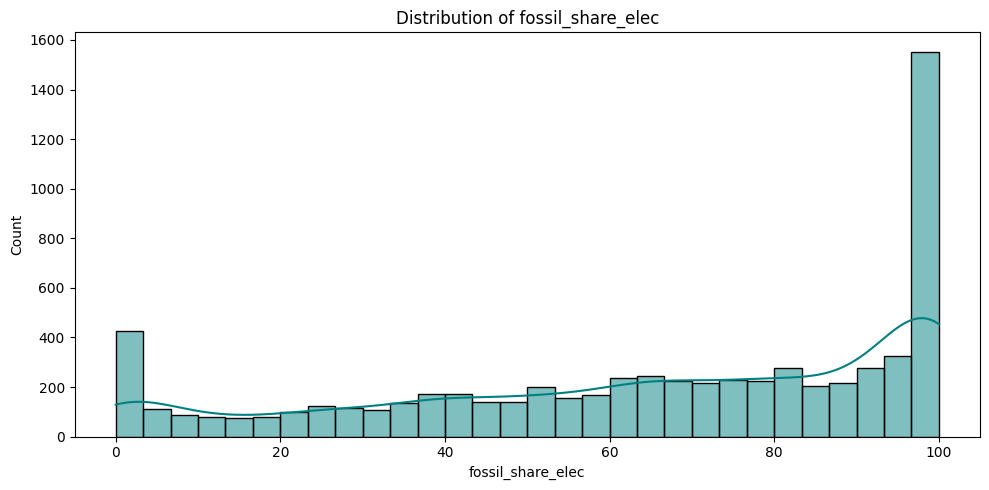

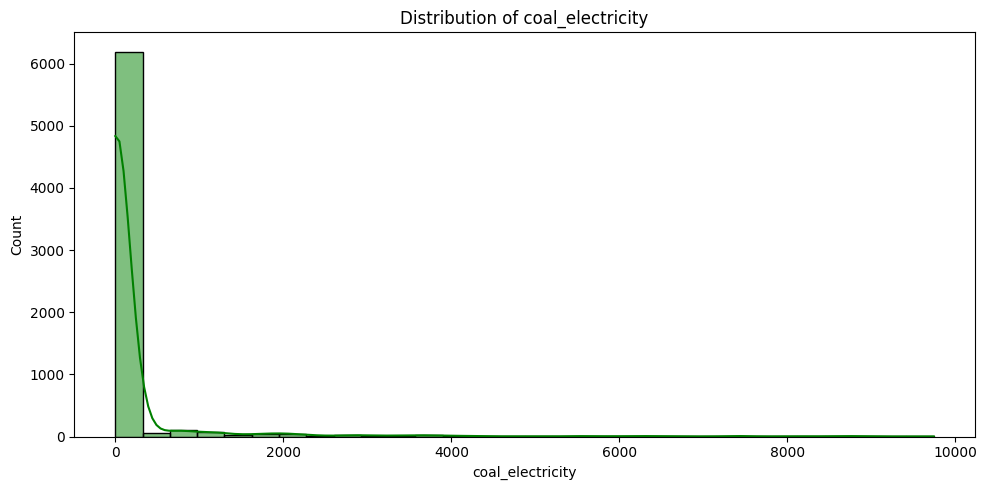

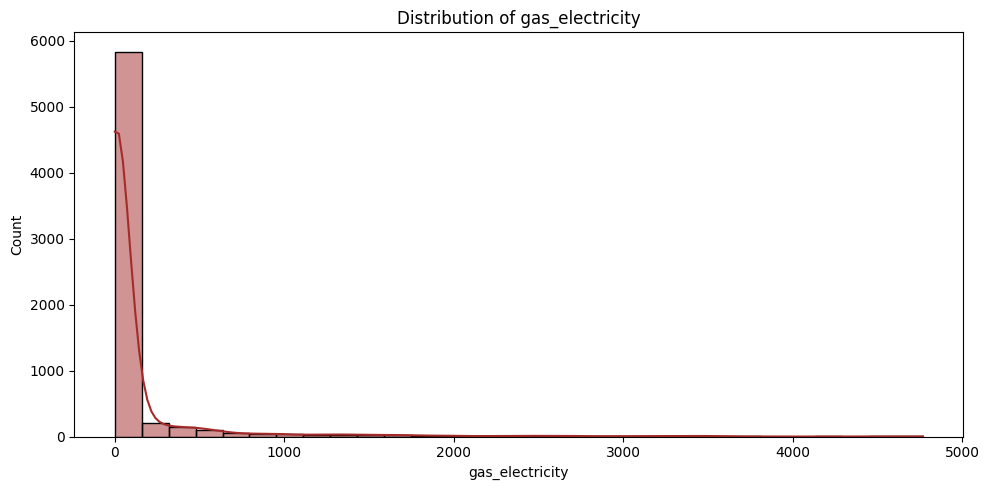

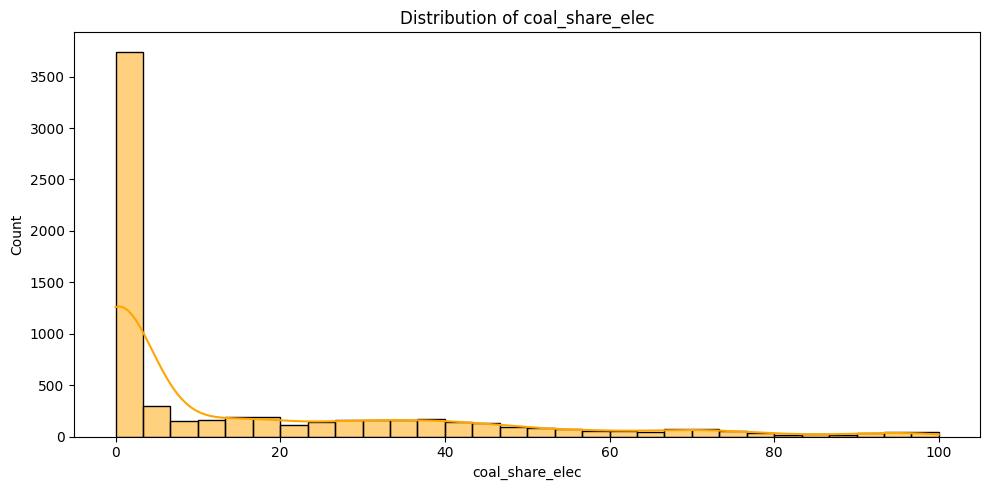

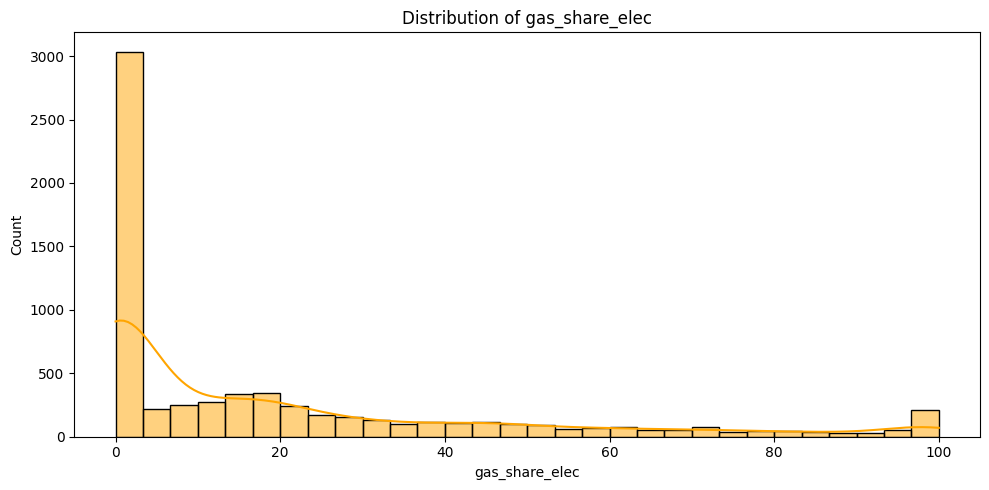

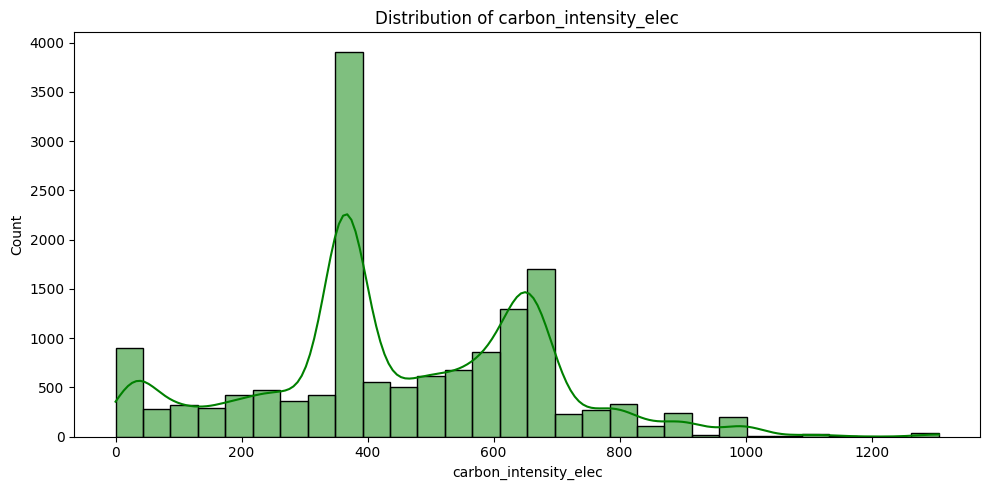

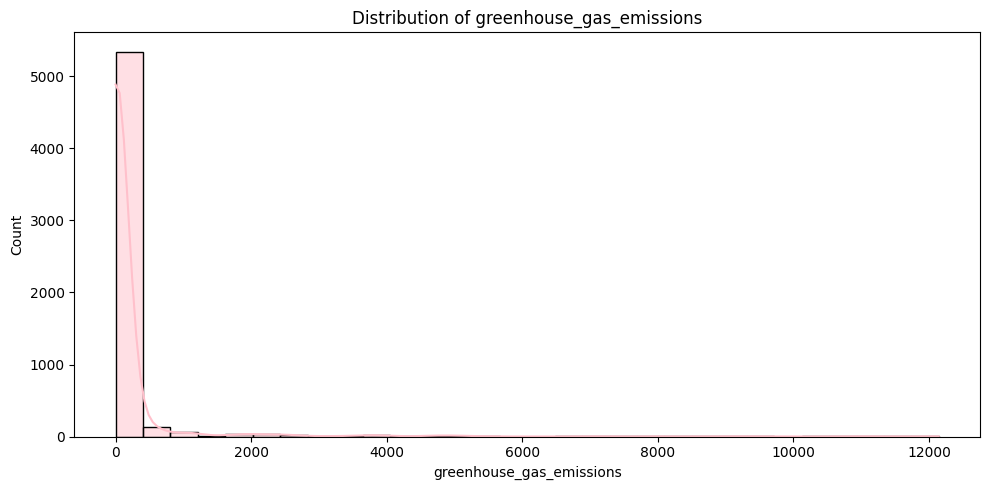

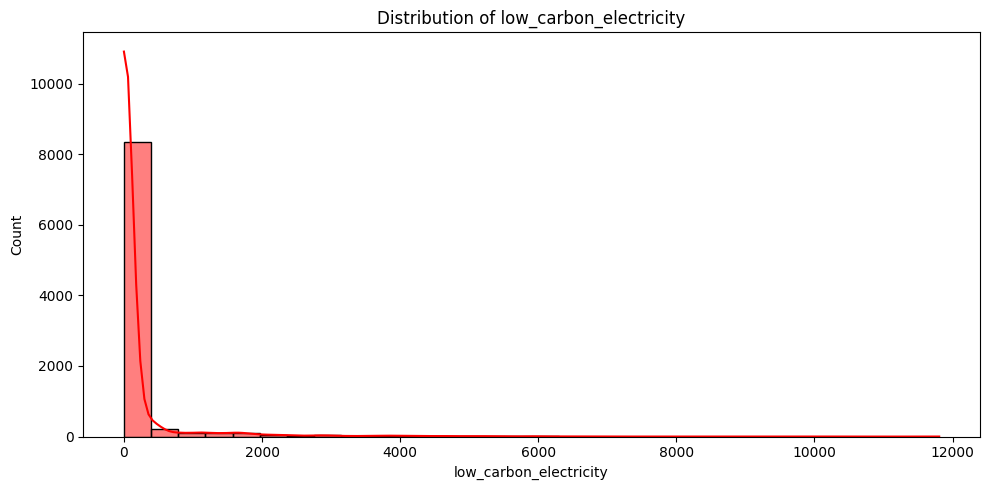

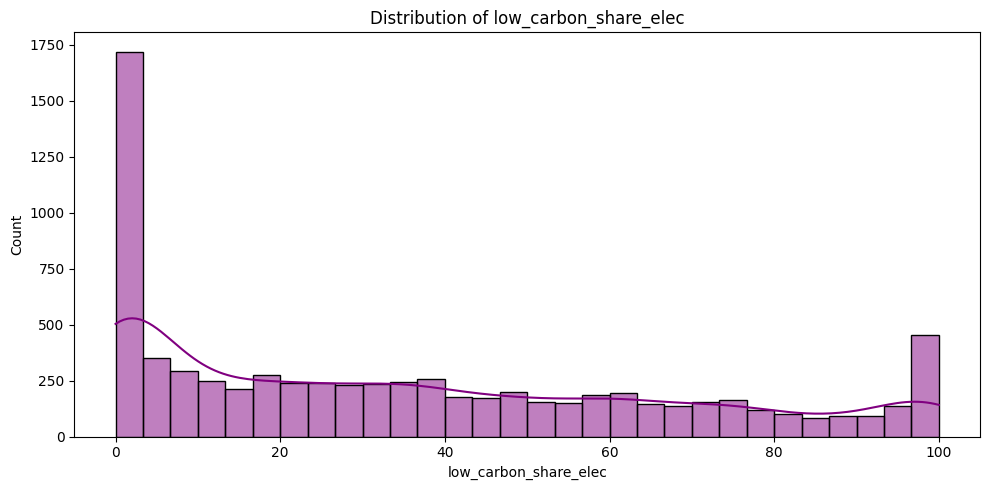

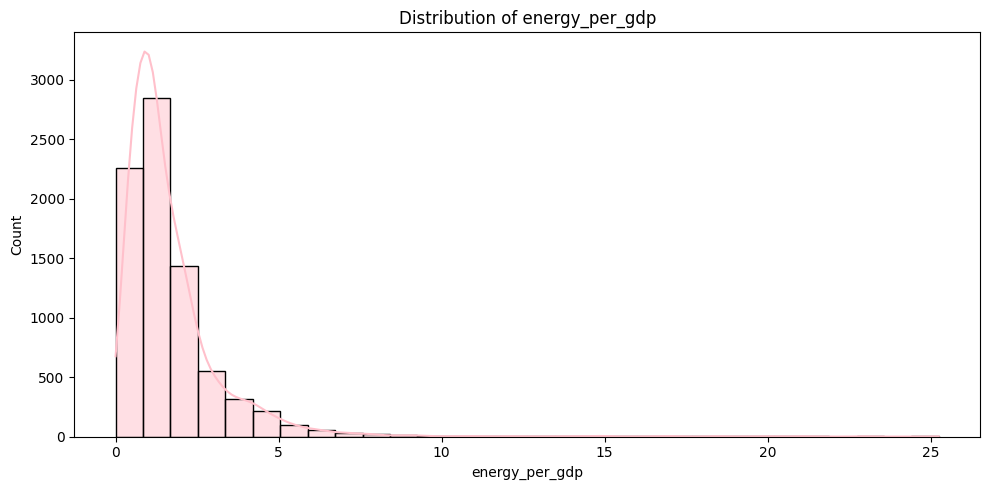

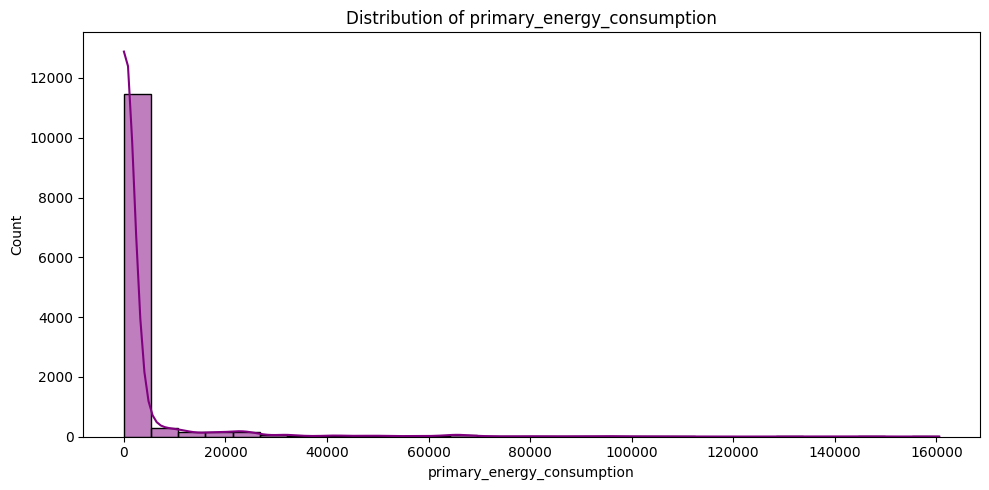

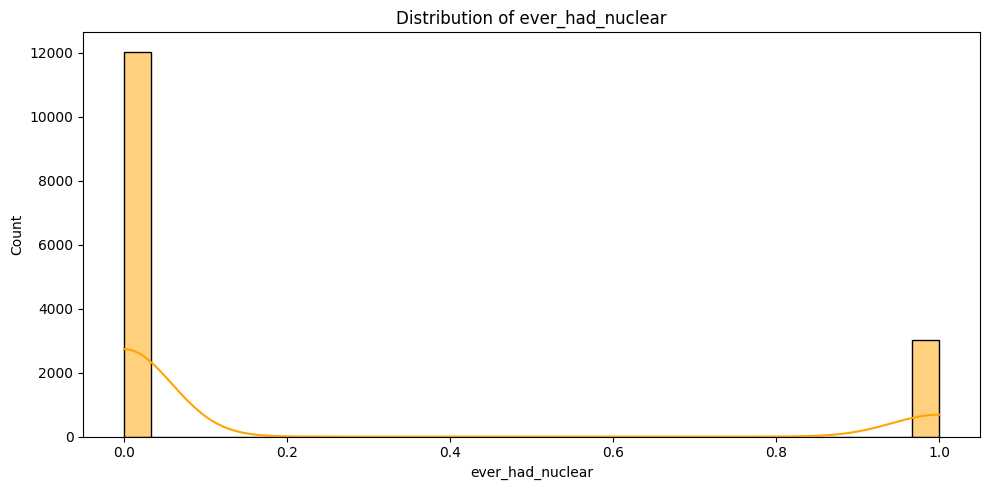

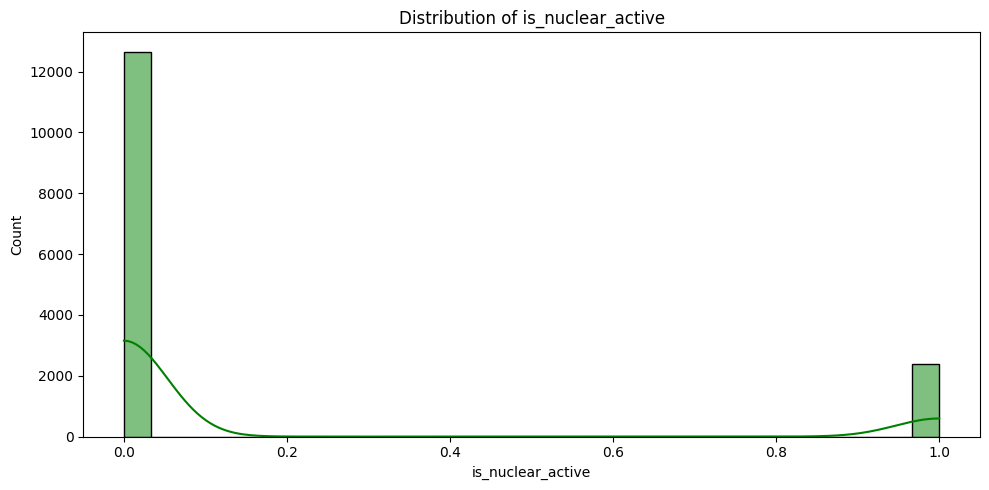

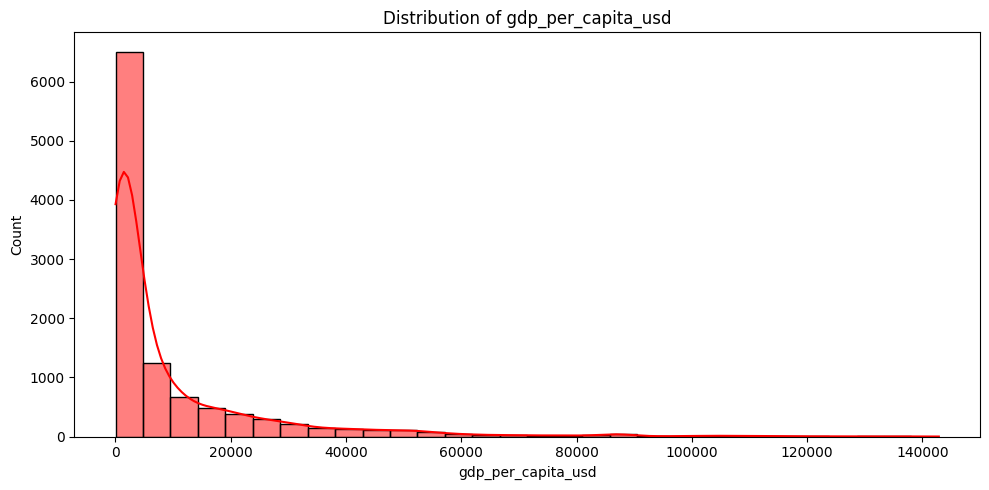

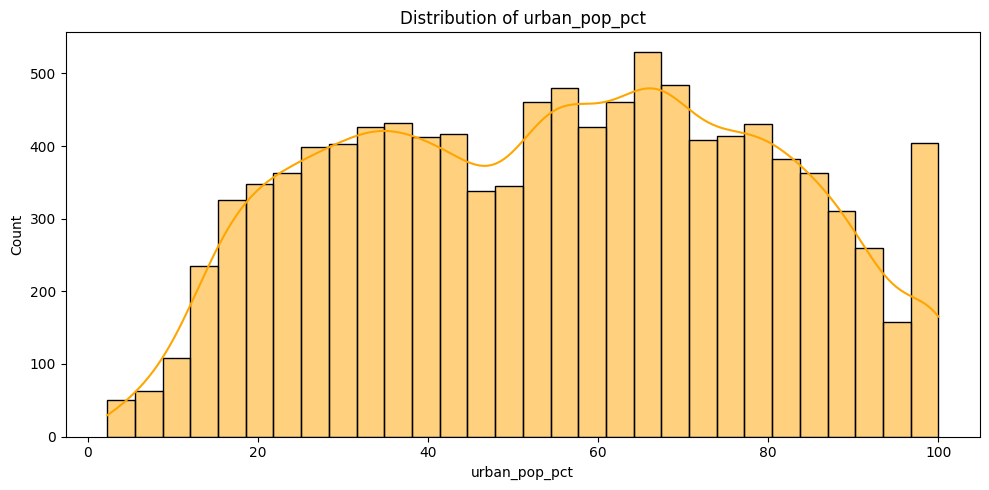

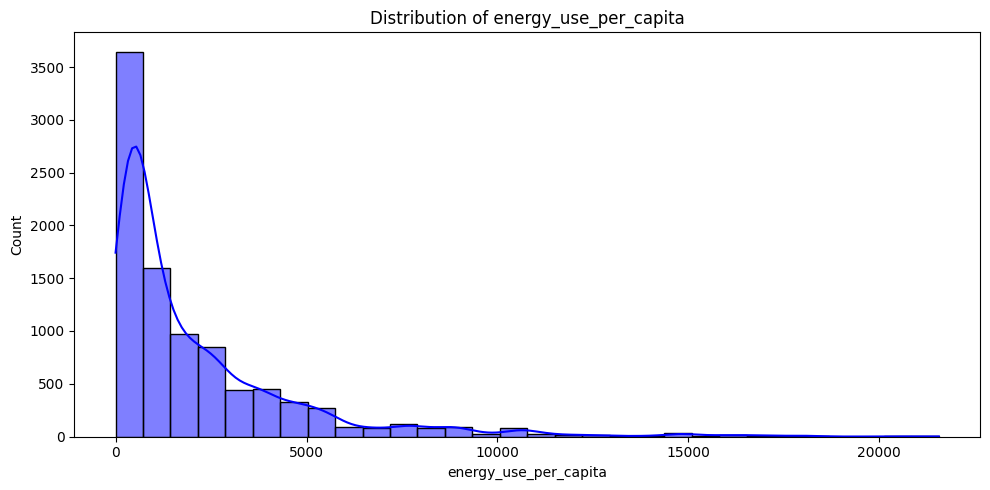

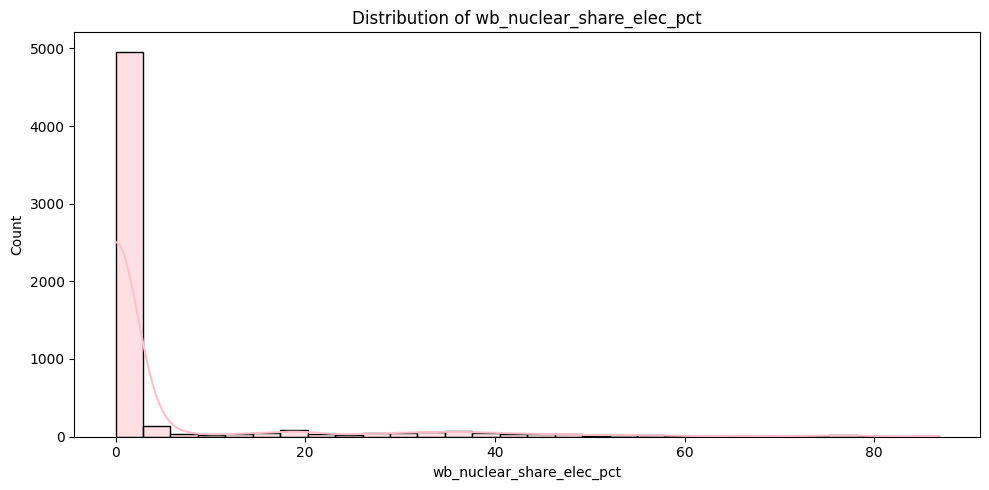

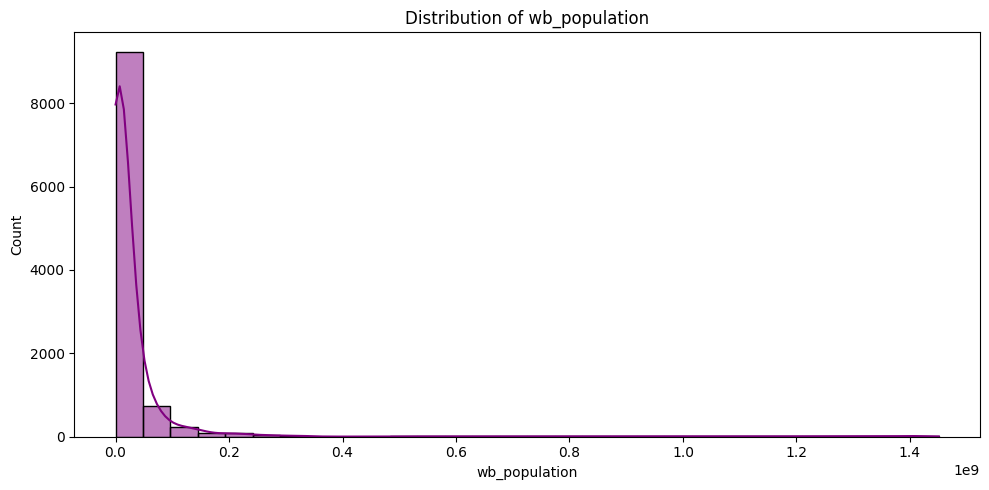

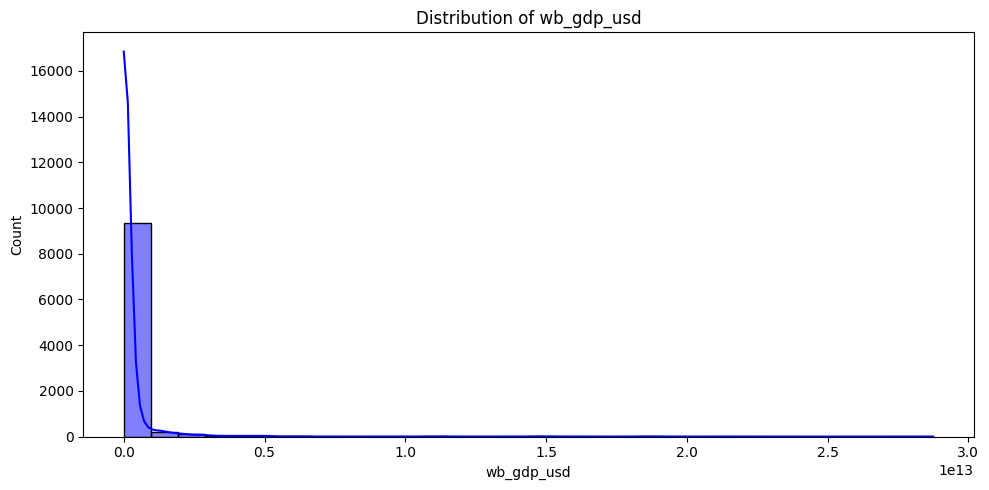

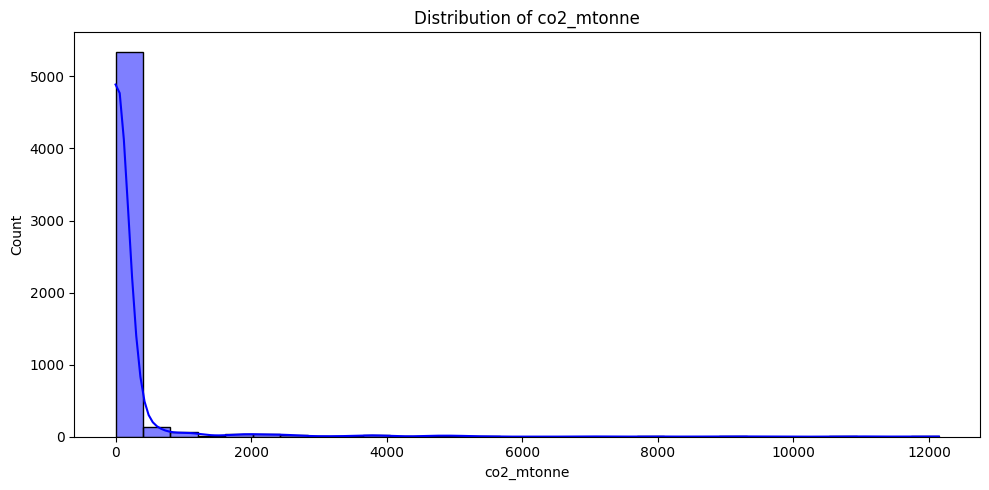

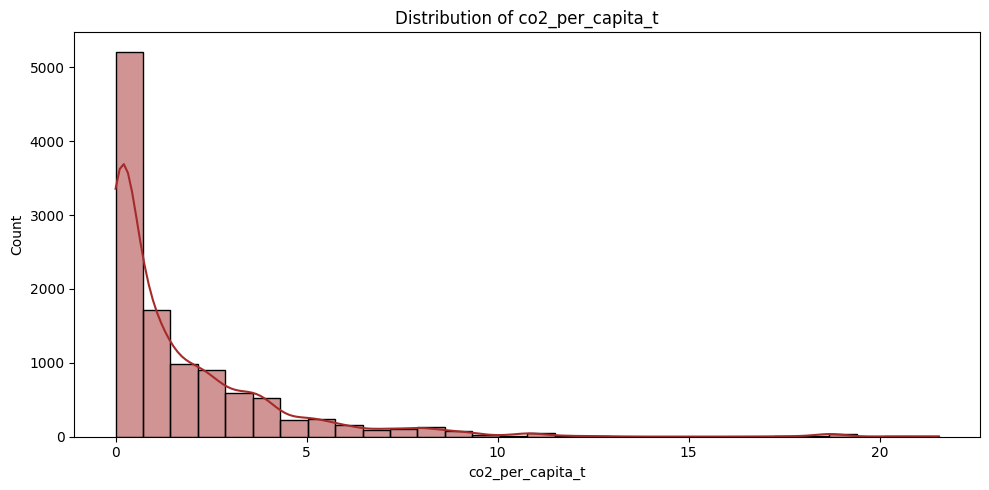

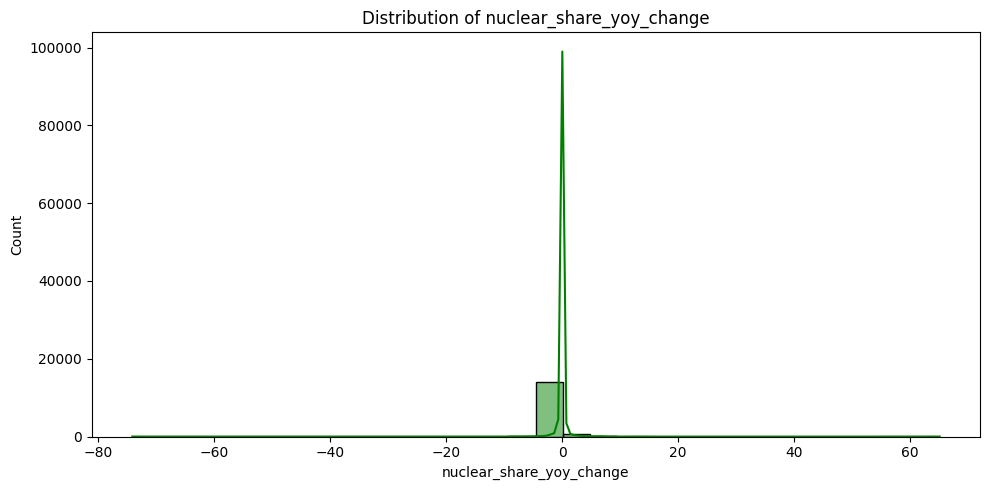

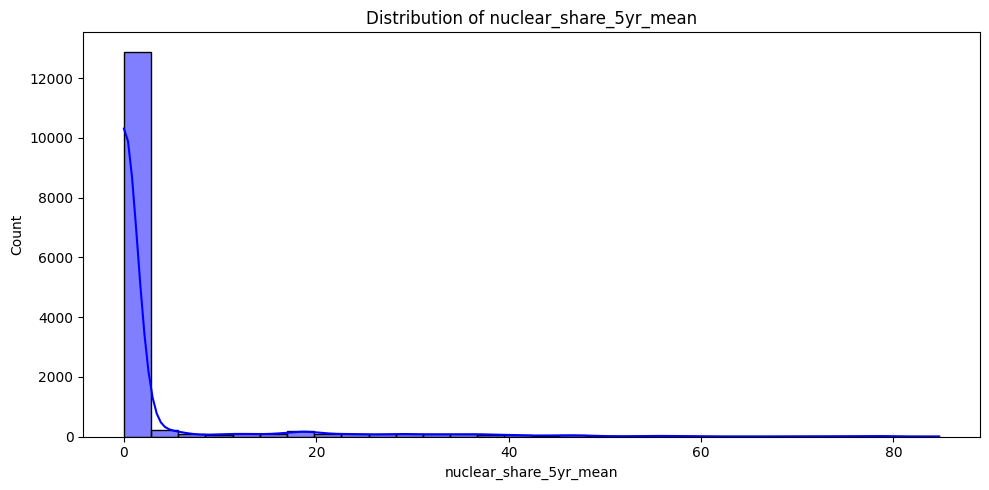

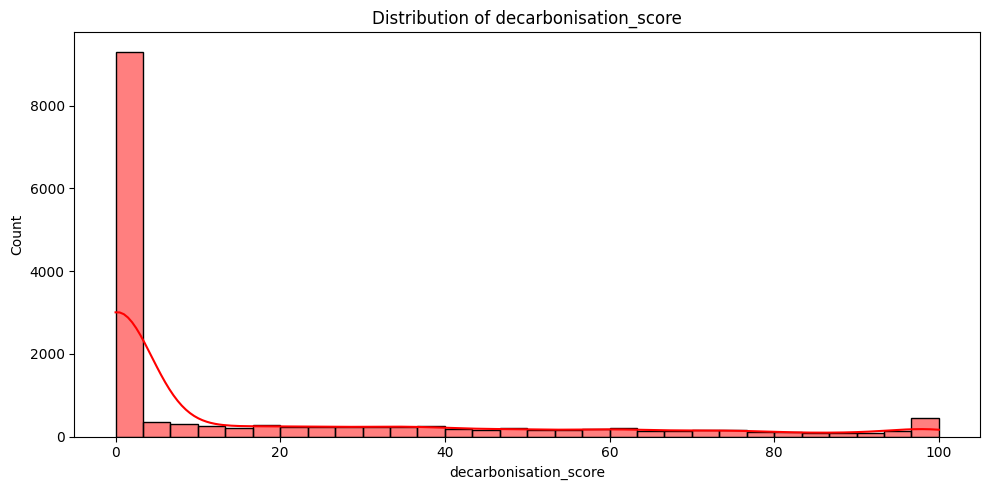

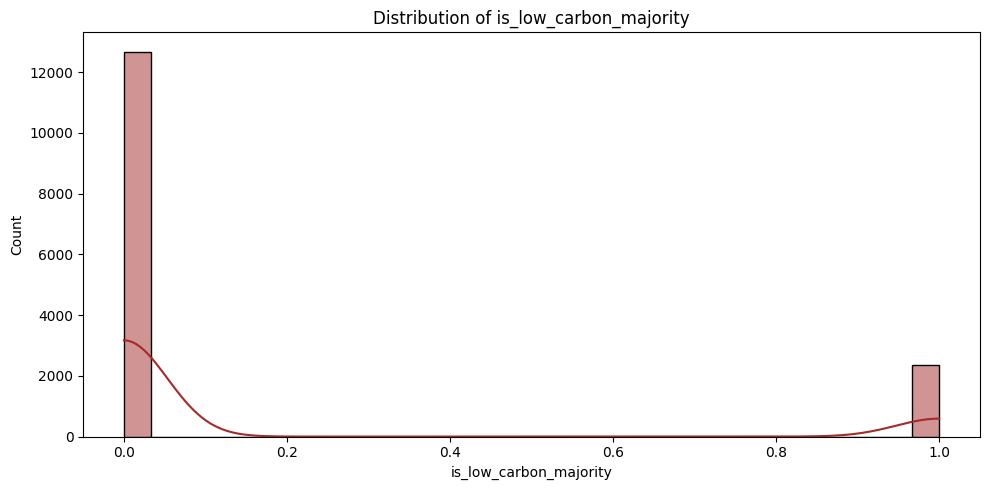

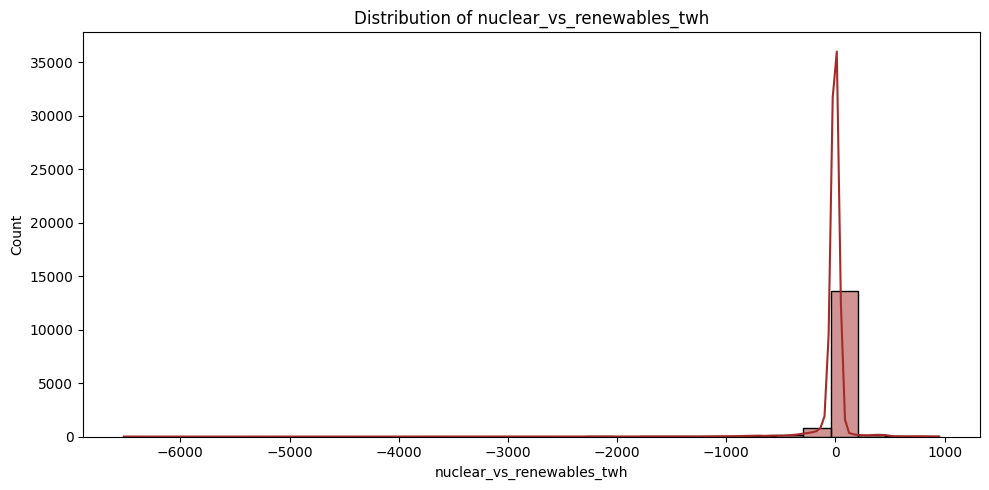

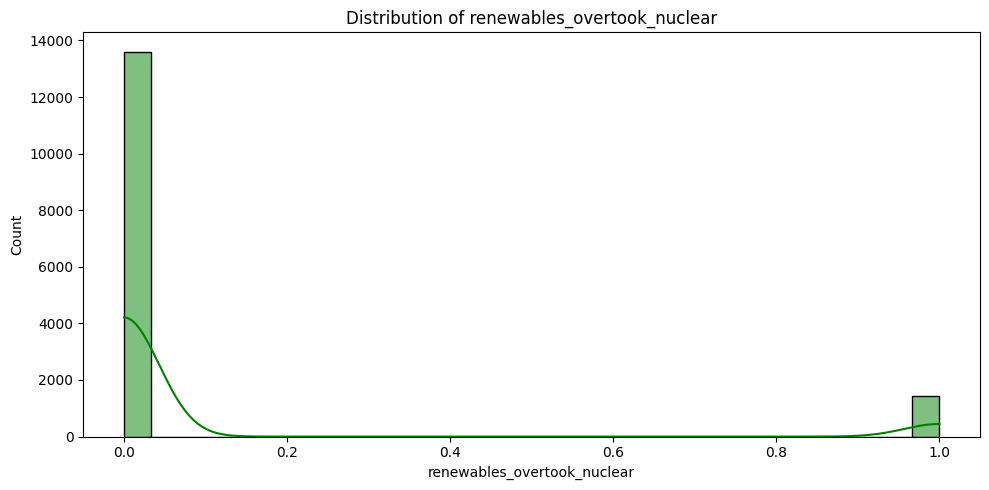

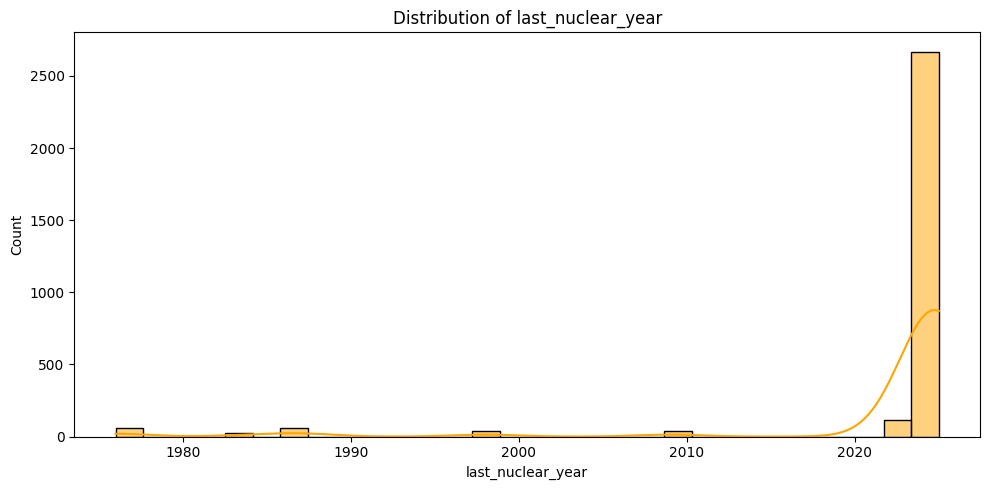

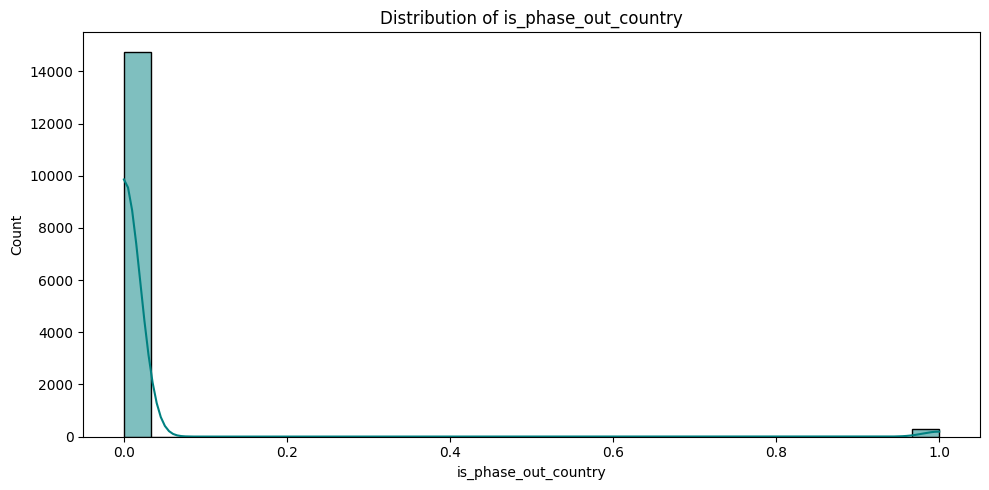

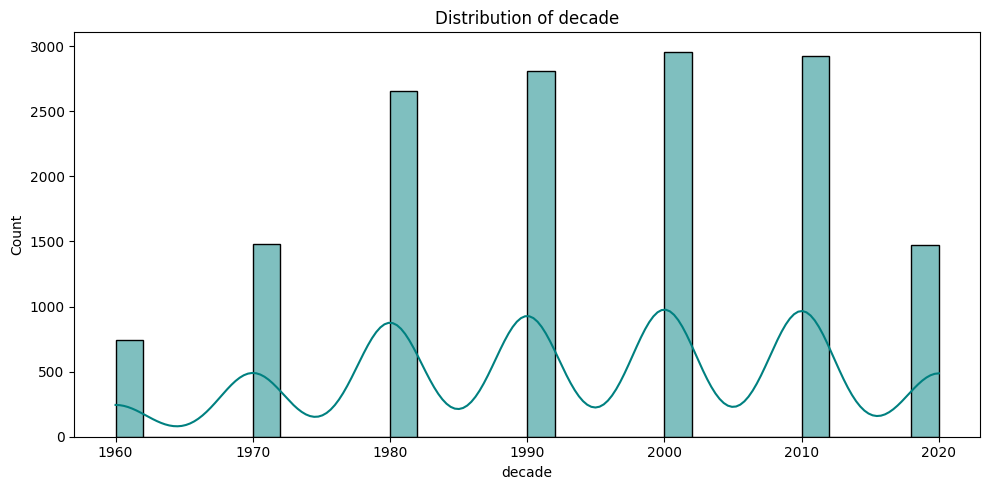

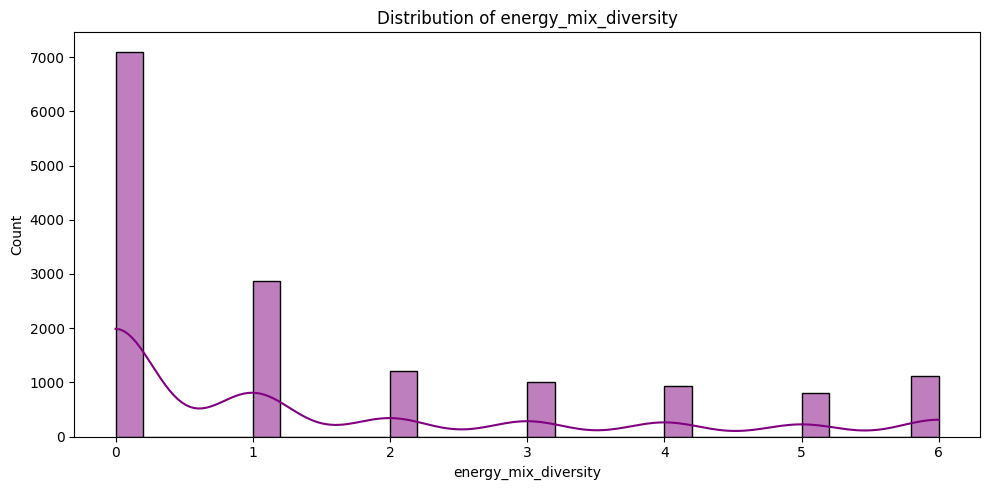

In [16]:
for col in numerical_cols:
    
    plt.figure(figsize=(10,5))
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        color=np.random.choice([
            'red','blue','green',
            'orange','purple',
            'brown','teal',
            'pink'
        ])
    )
    
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()


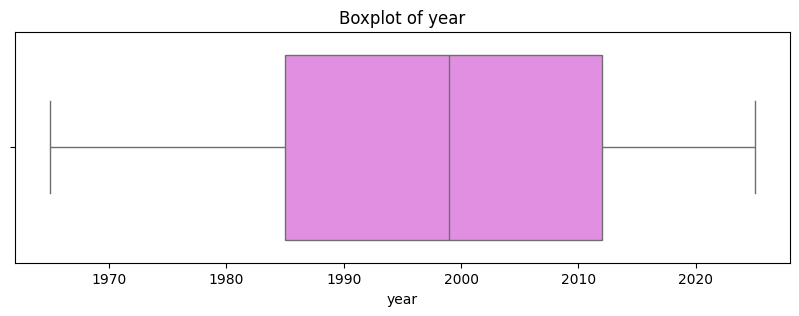

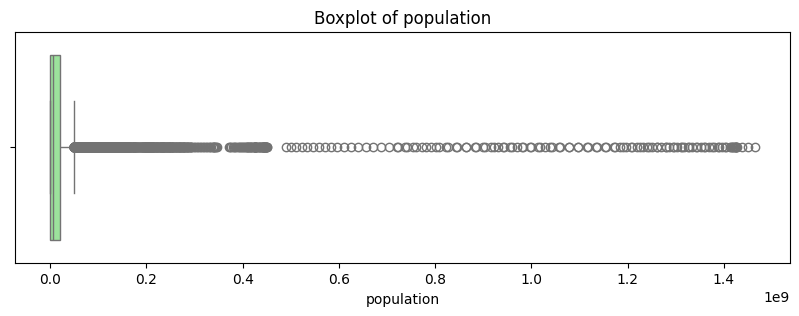

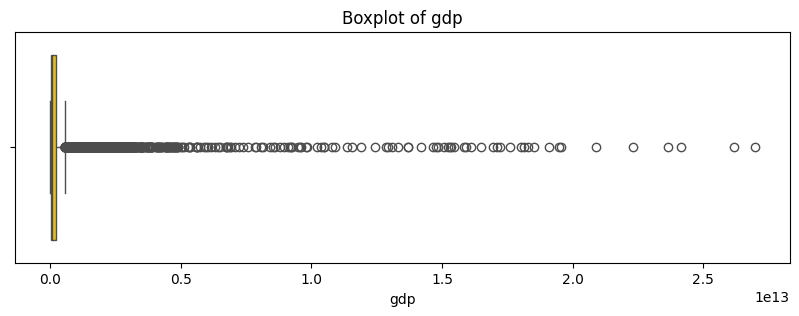

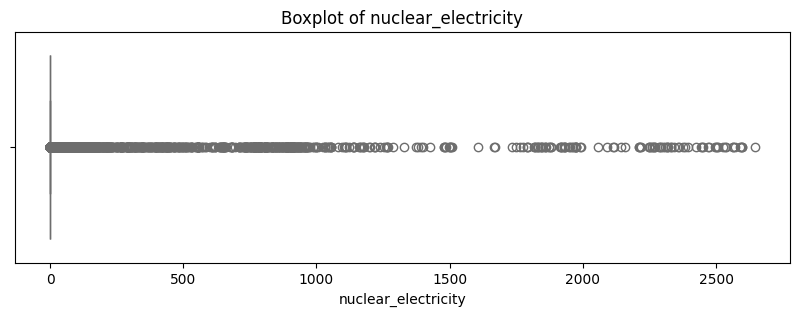

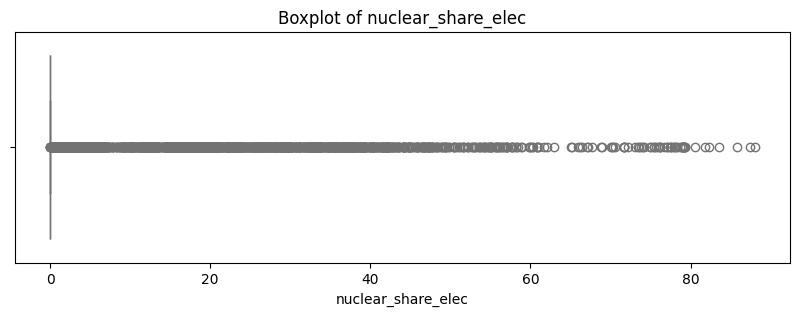

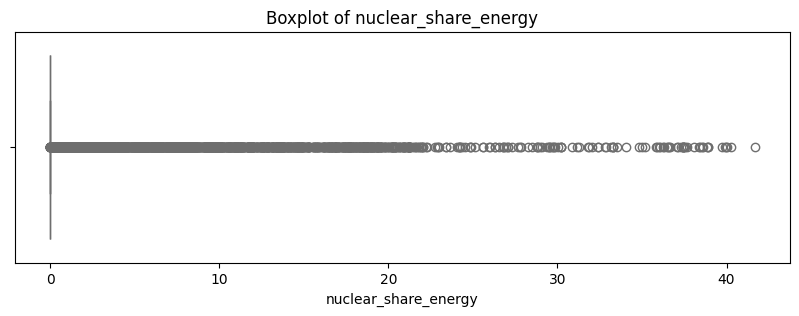

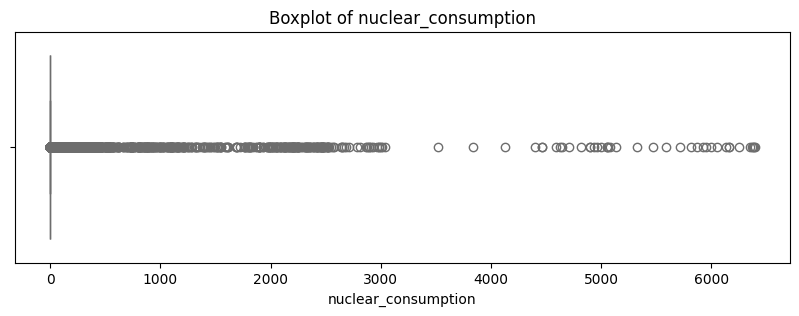

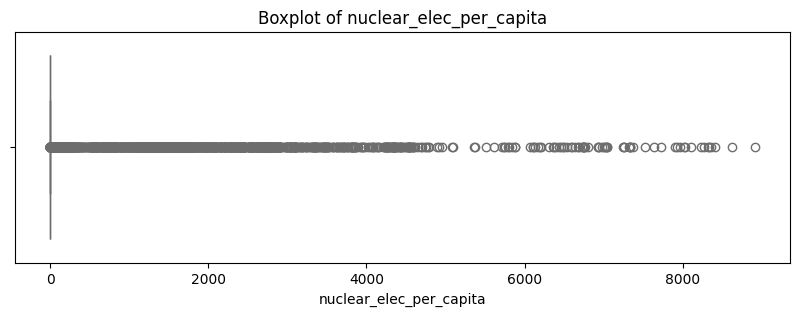

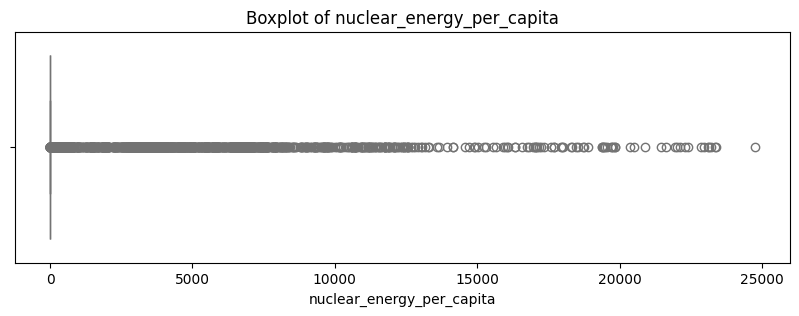

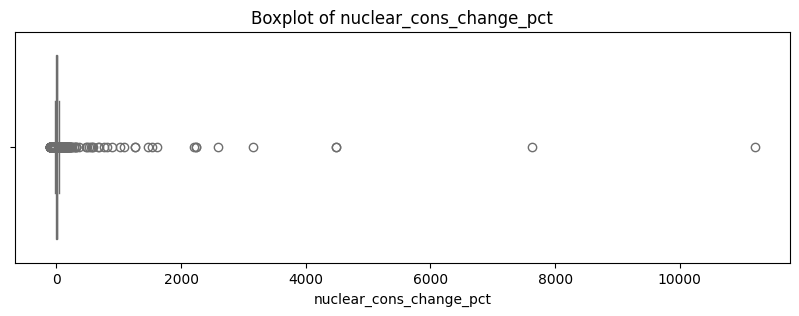

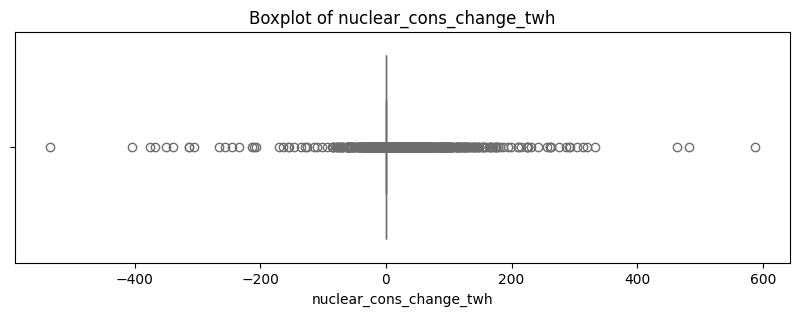

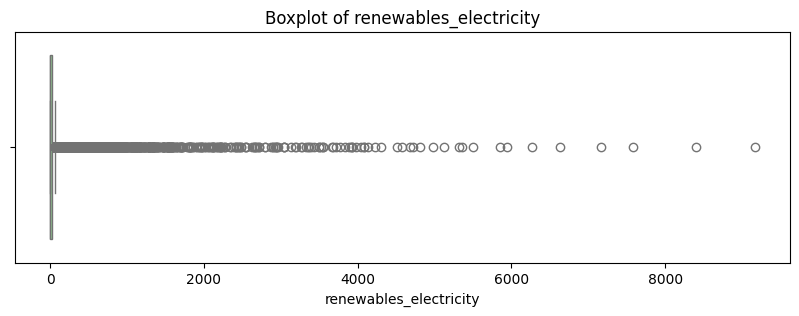

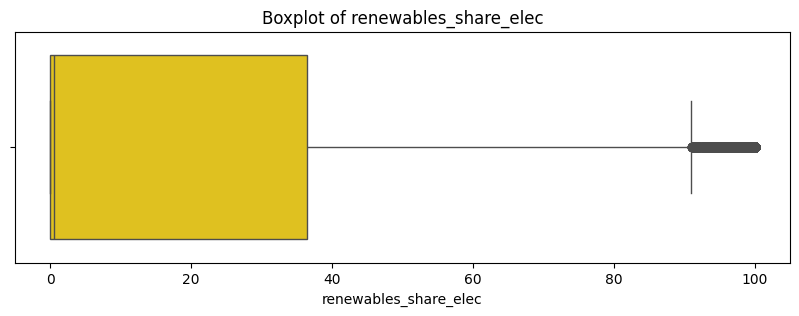

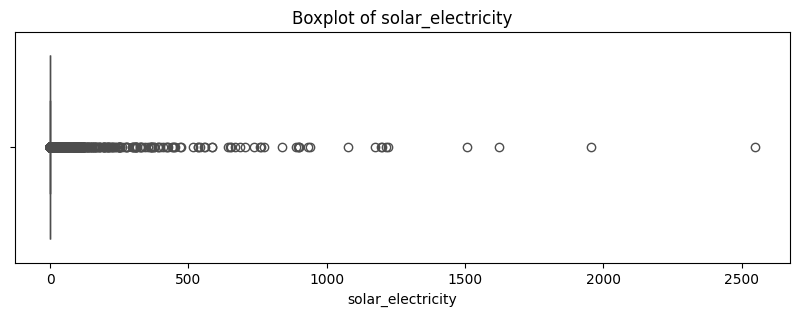

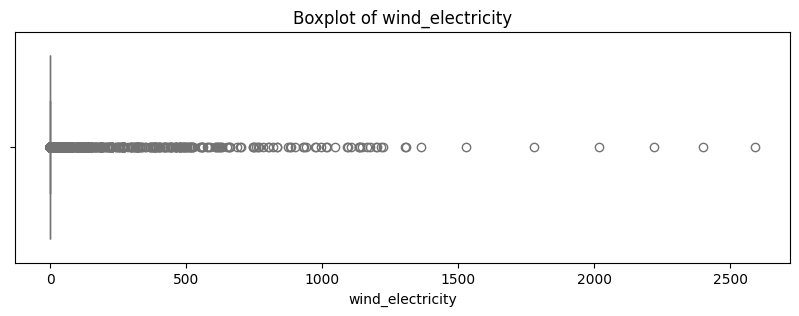

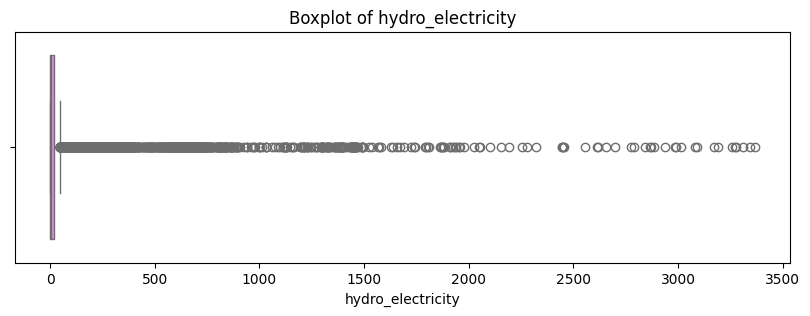

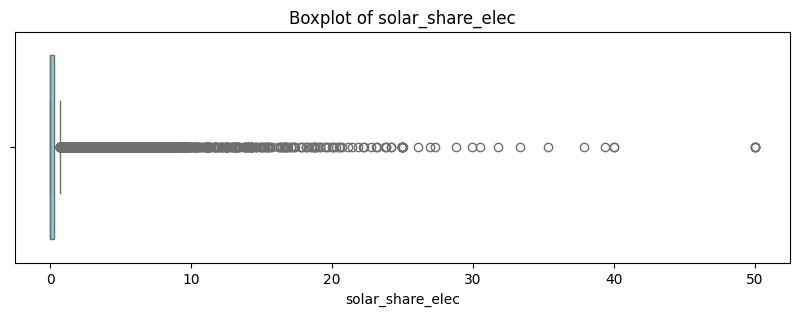

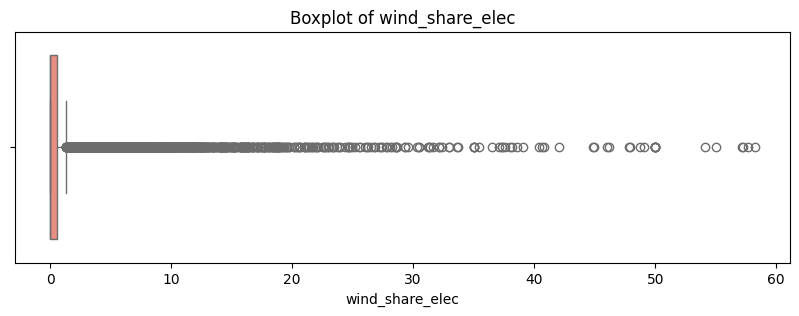

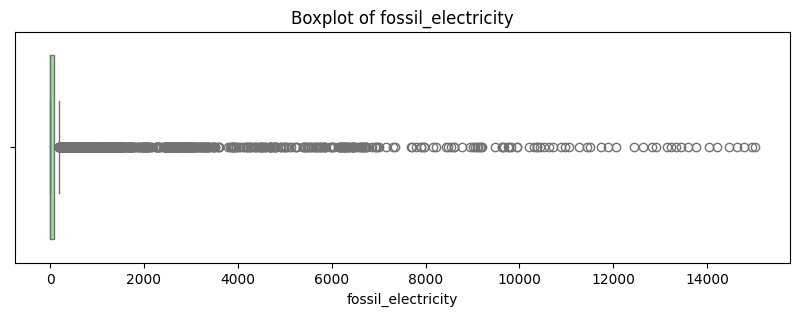

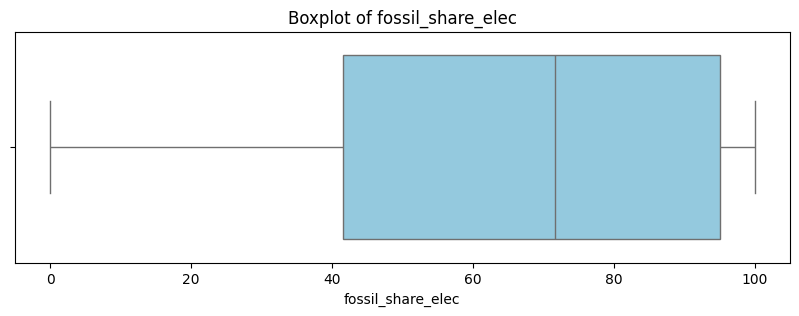

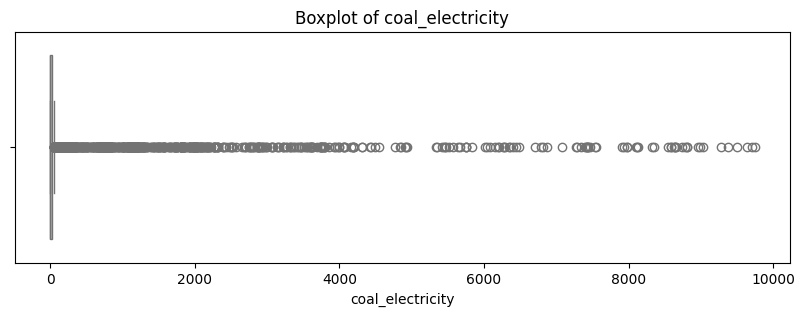

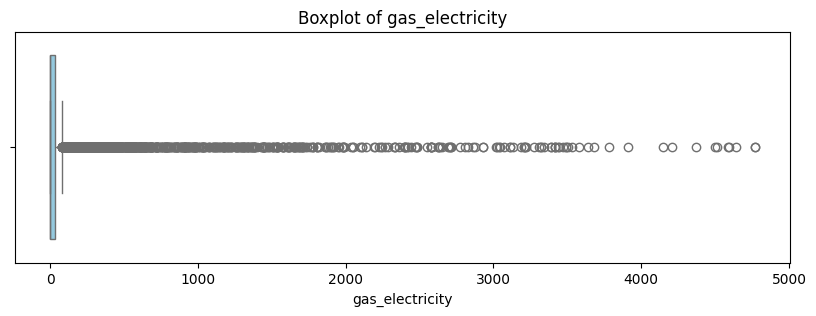

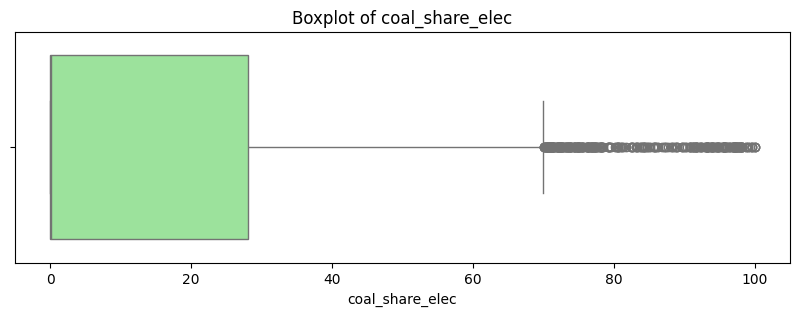

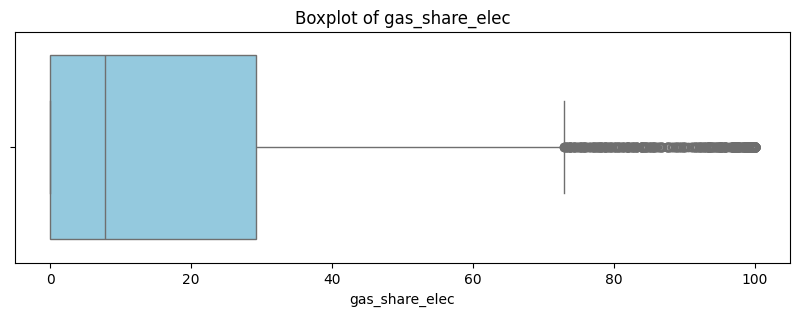

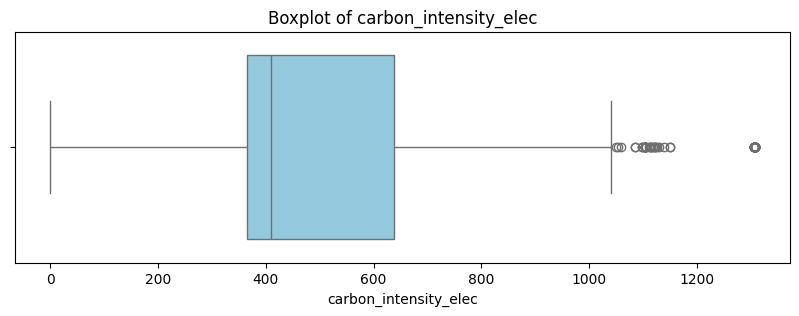

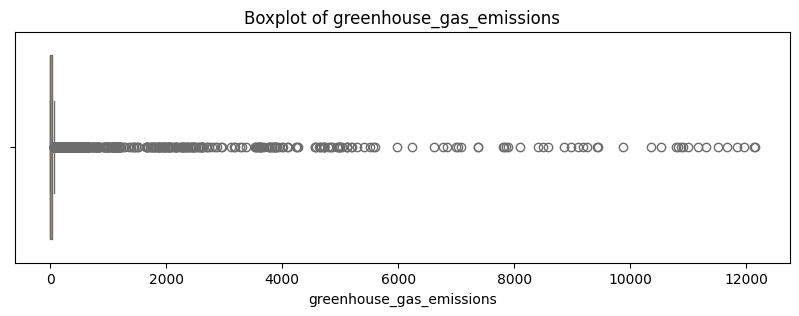

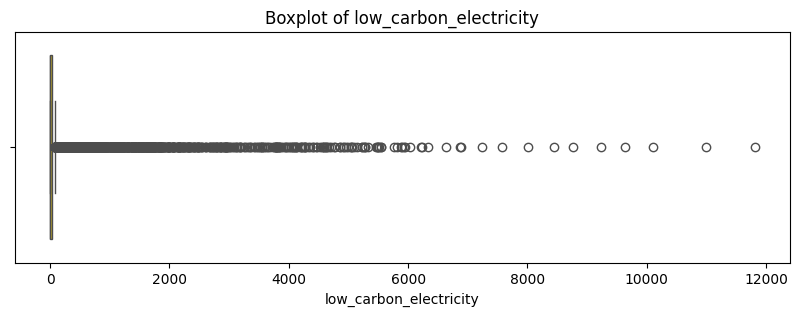

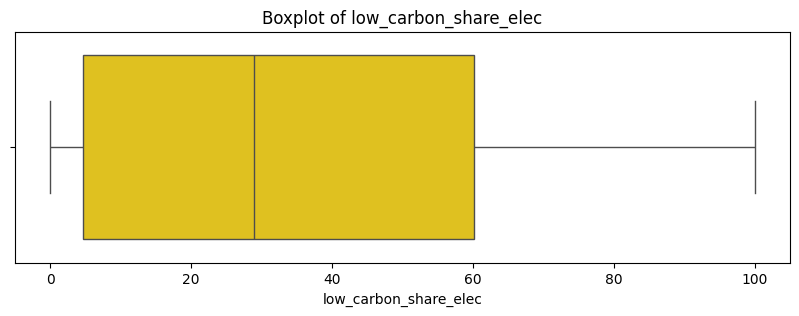

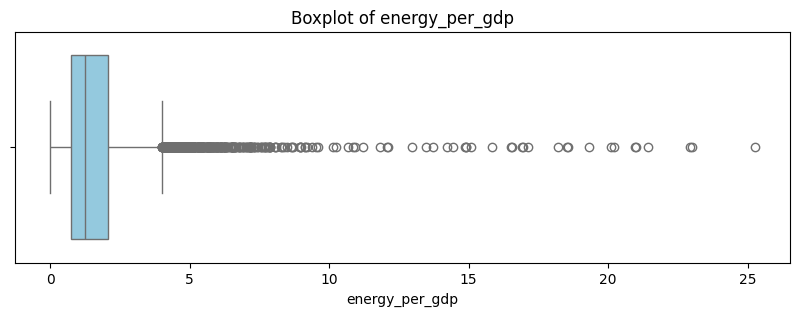

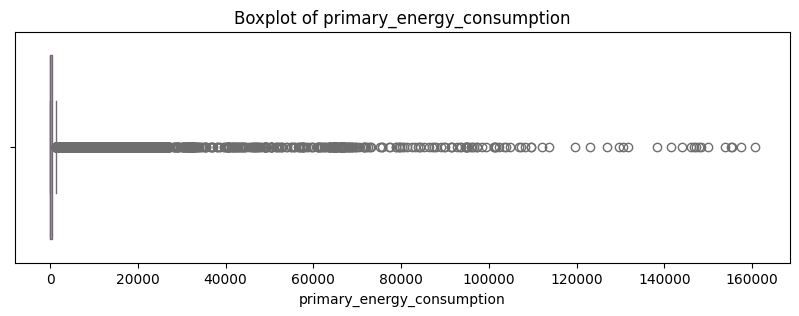

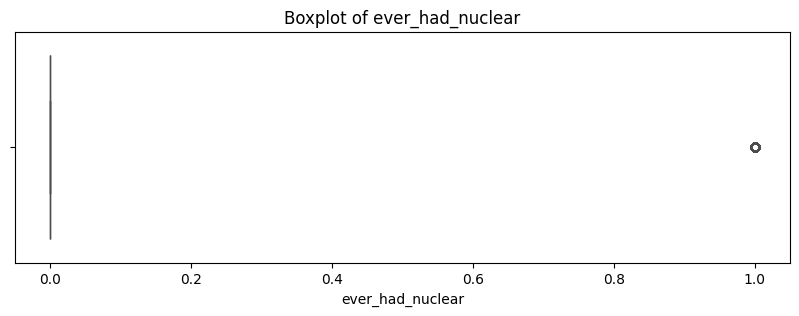

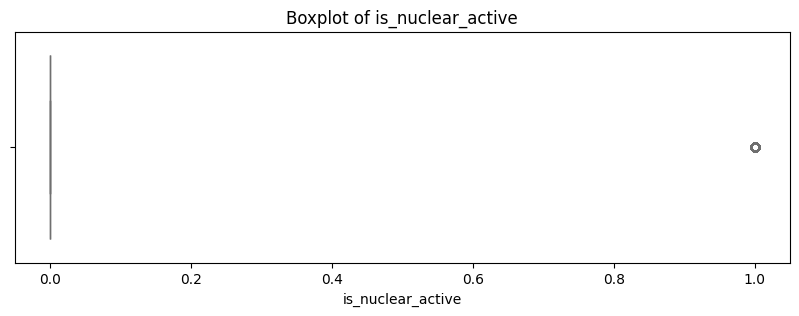

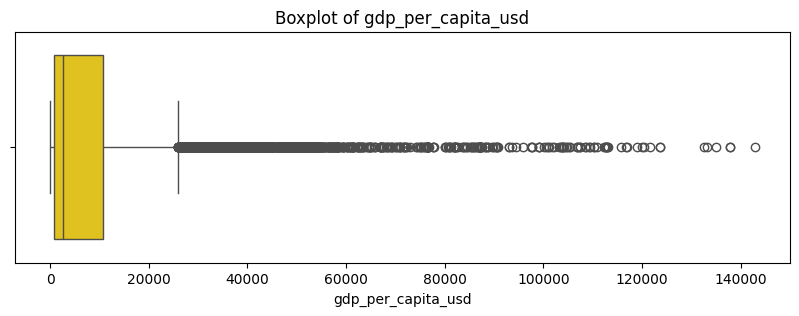

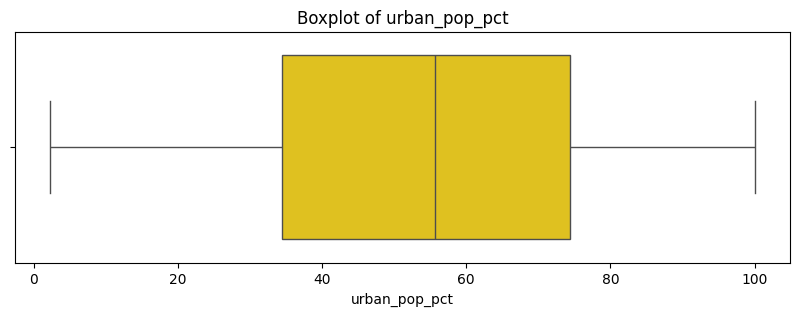

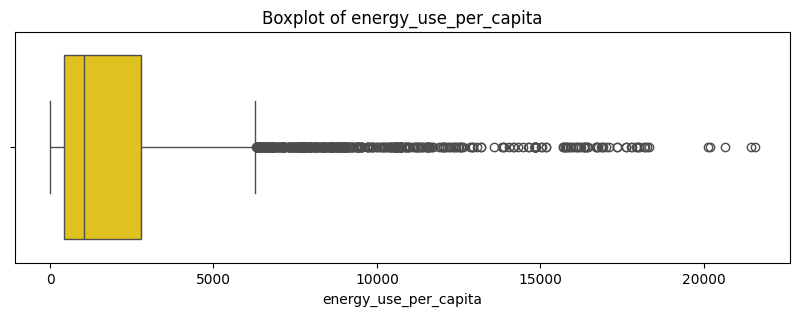

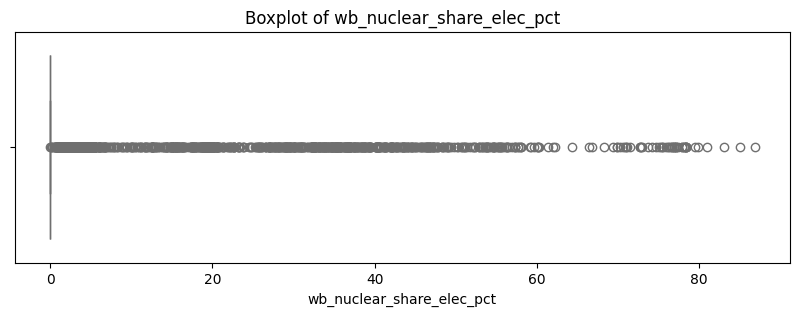

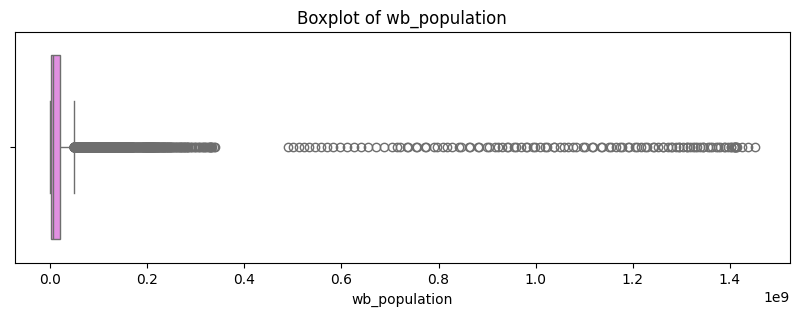

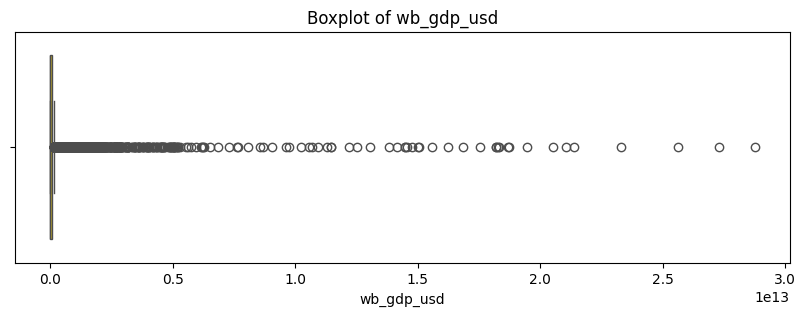

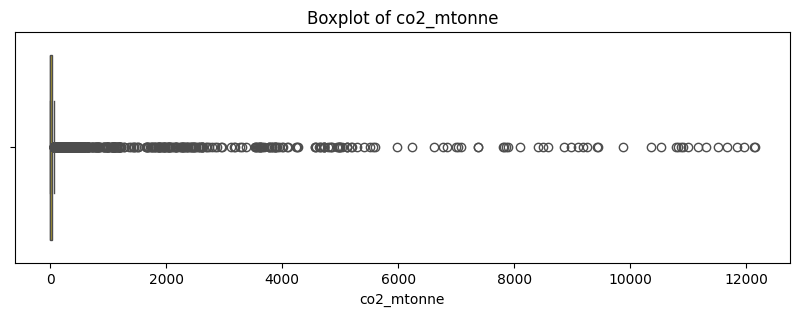

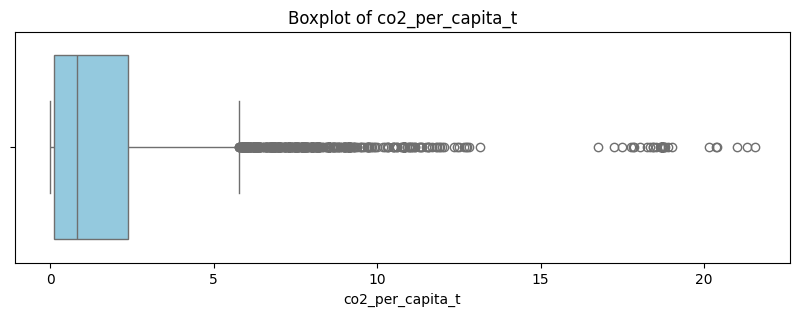

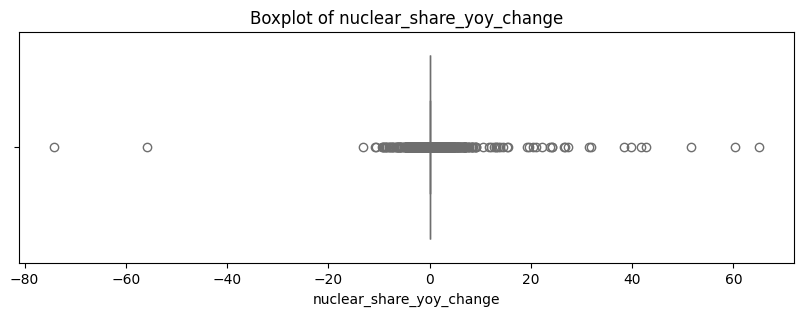

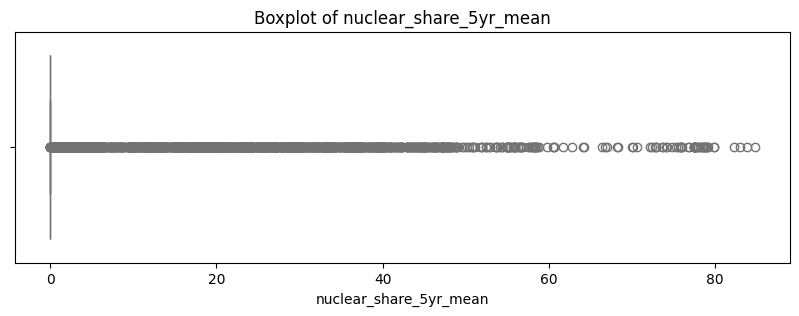

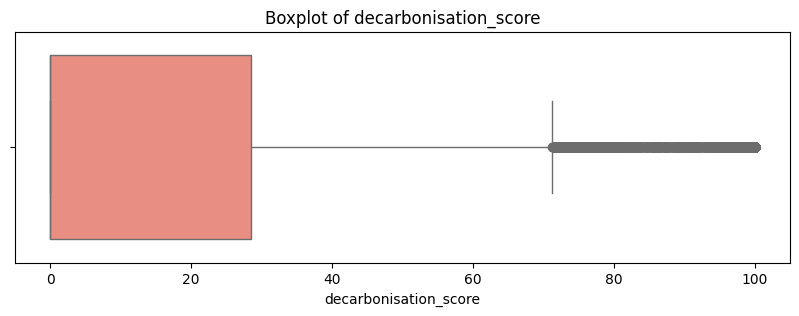

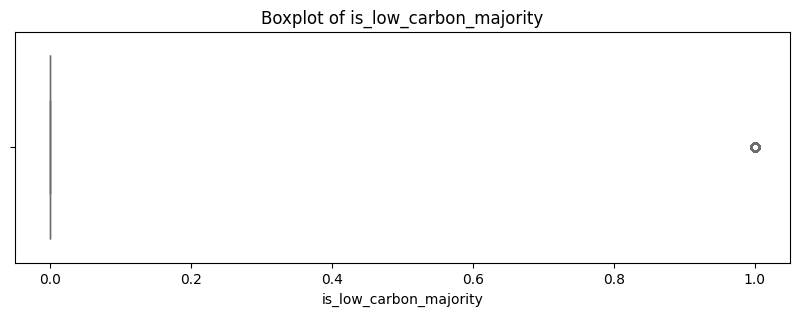

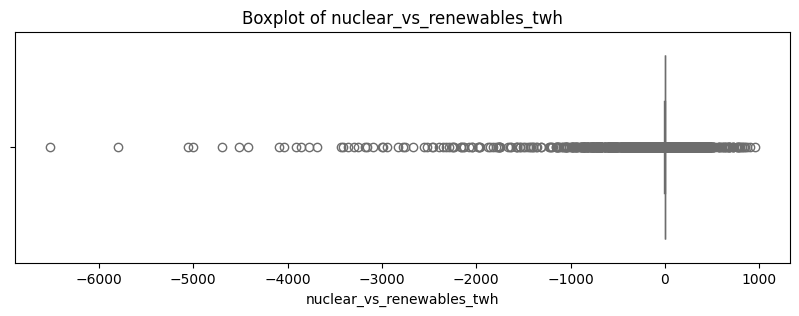

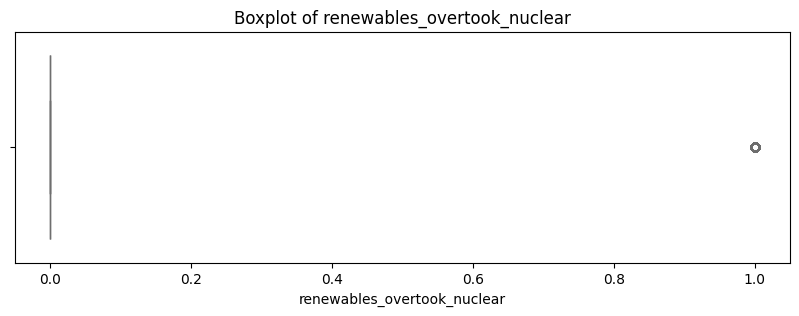

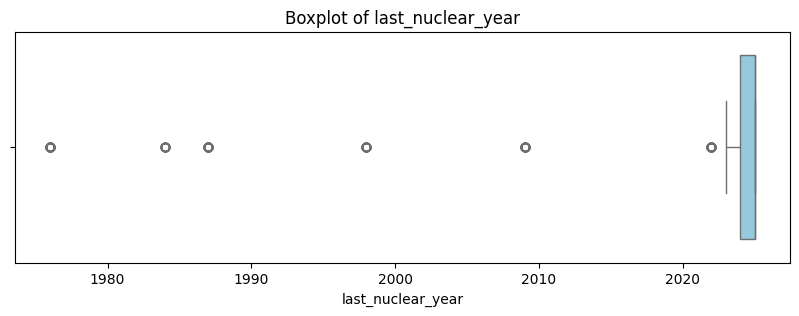

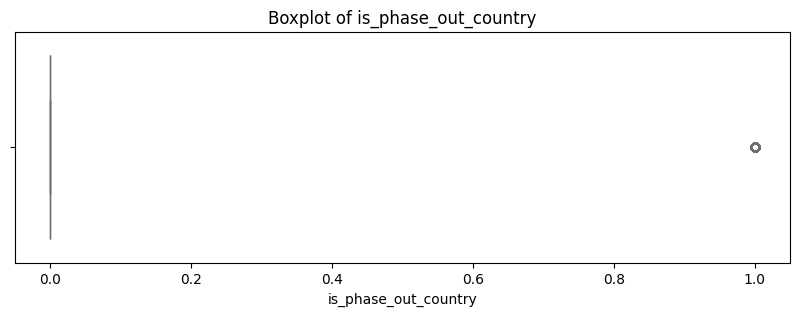

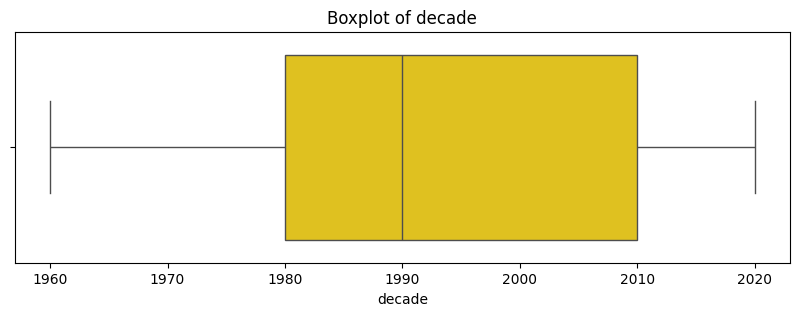

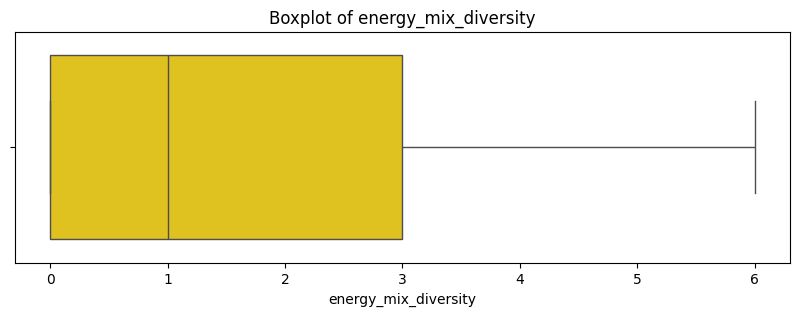

In [17]:
for col in numerical_cols:
    
    plt.figure(figsize=(10,3))
    
    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            'gold',
            'skyblue',
            'lightgreen',
            'violet',
            'salmon'
        ])
    )
    
    plt.title(f'Boxplot of {col}')
    plt.show()

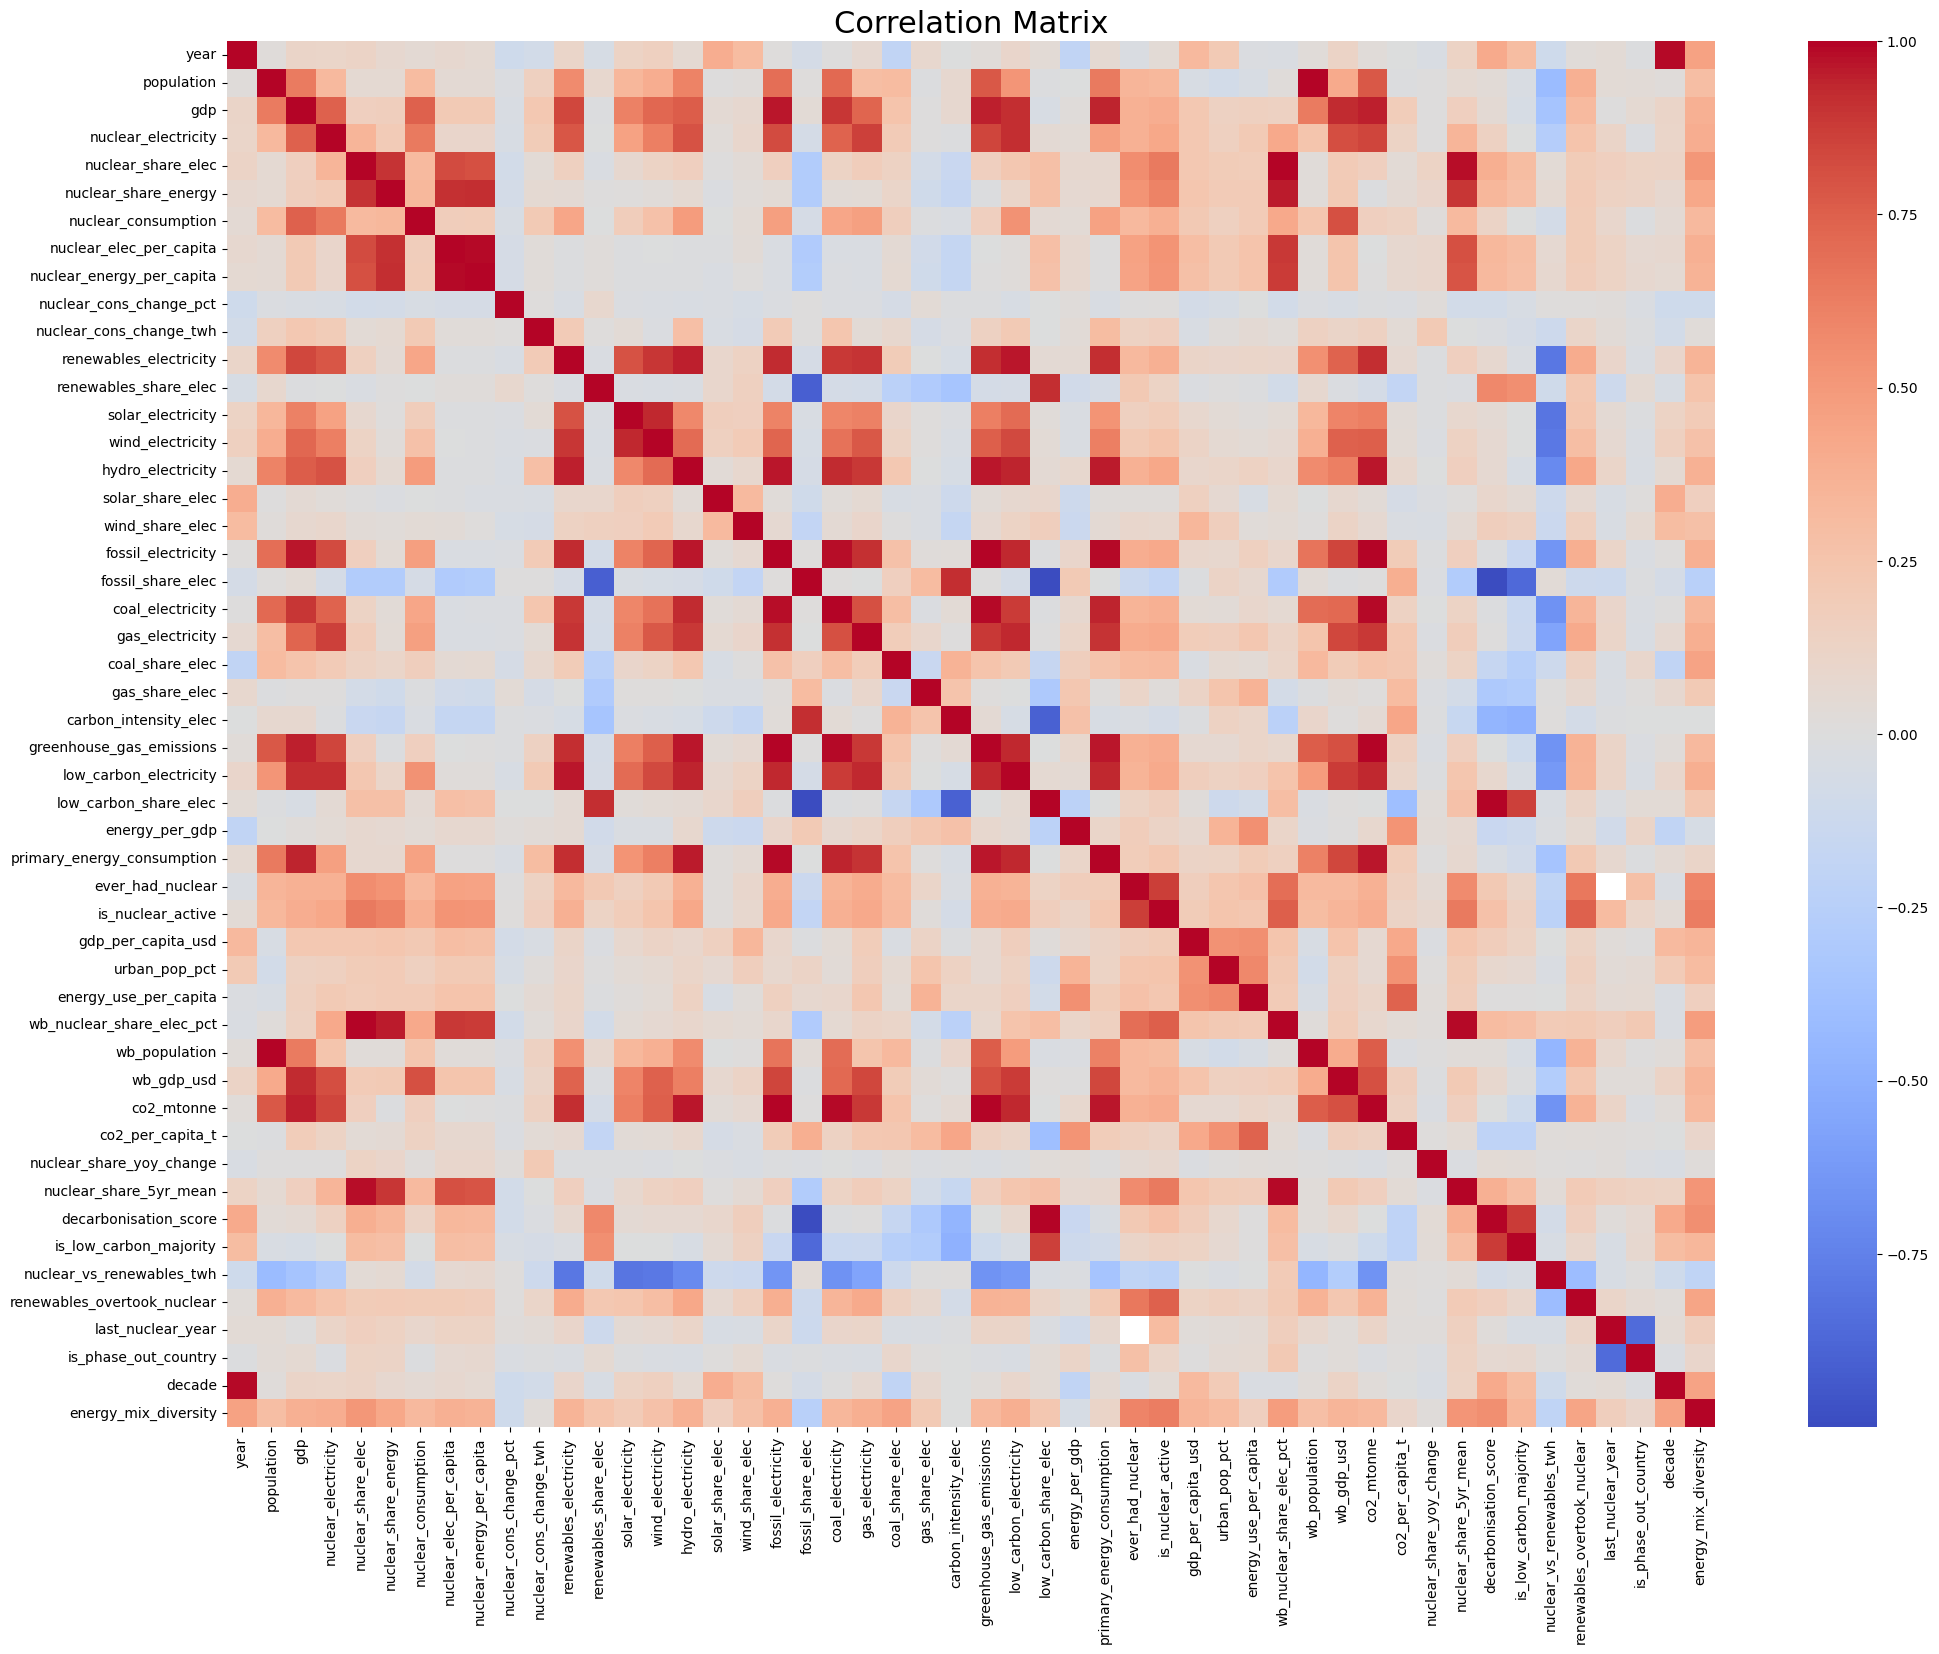

In [18]:
plt.figure(figsize=(24,18))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    center=0
)

plt.title("Correlation Matrix", fontsize=22)
plt.show()

In [19]:
corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = (
    upper.stack()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTop Correlations")
print(high_corr)



Top Correlations
greenhouse_gas_emissions    co2_mtonne                    1.000000
low_carbon_share_elec       decarbonisation_score         1.000000
population                  wb_population                 0.999983
fossil_share_elec           low_carbon_share_elec         0.999959
                            decarbonisation_score         0.999959
fossil_electricity          greenhouse_gas_emissions      0.998243
                            co2_mtonne                    0.998243
nuclear_share_elec          wb_nuclear_share_elec_pct     0.996378
wb_nuclear_share_elec_pct   nuclear_share_5yr_mean        0.990013
nuclear_elec_per_capita     nuclear_energy_per_capita     0.987900
coal_electricity            greenhouse_gas_emissions      0.987601
                            co2_mtonne                    0.987601
fossil_electricity          primary_energy_consumption    0.985542
year                        decade                        0.984994
nuclear_share_elec          nuclear_share_5y

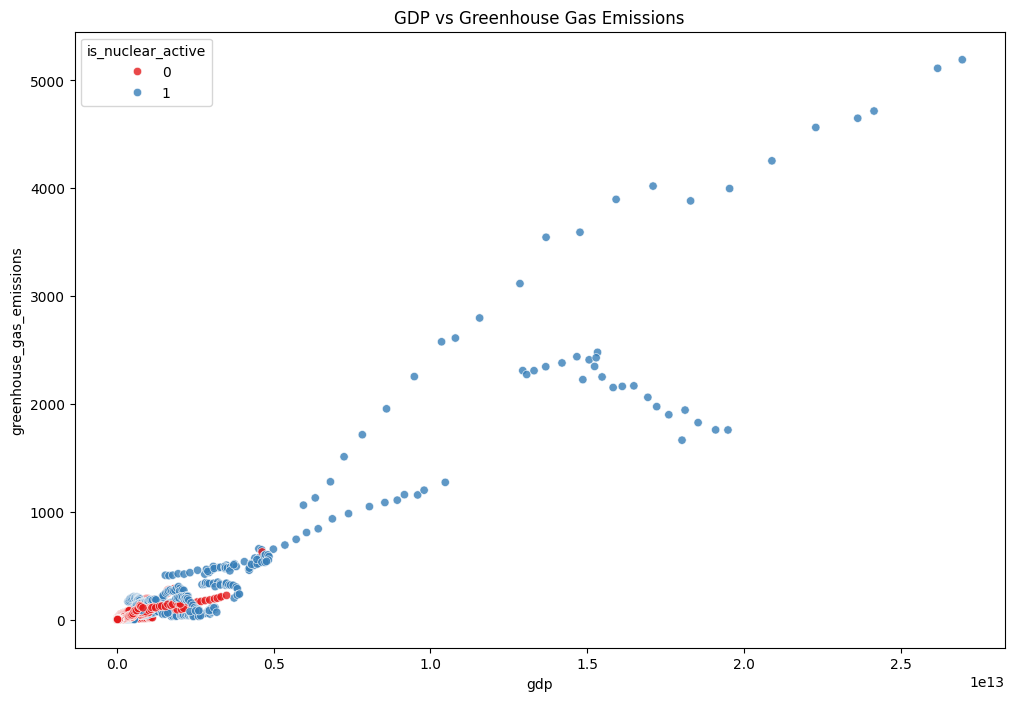

In [20]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='gdp',
    y='greenhouse_gas_emissions',
    hue='is_nuclear_active',
    palette='Set1',
    alpha=0.8
)

plt.title("GDP vs Greenhouse Gas Emissions")
plt.show()

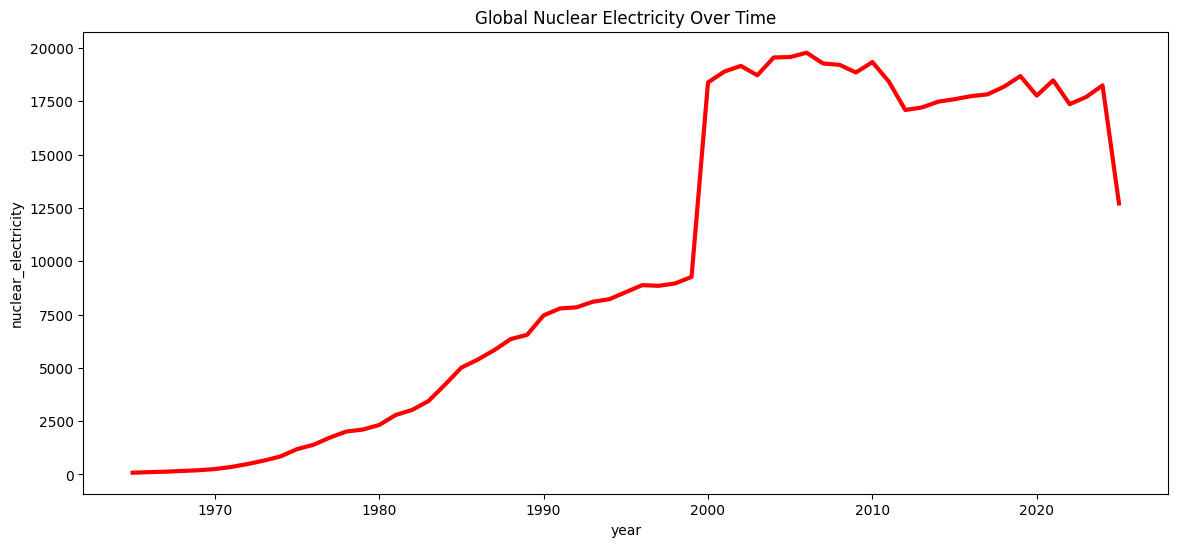

In [21]:
yearly_nuclear = (
    df.groupby('year')['nuclear_electricity']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=yearly_nuclear,
    x='year',
    y='nuclear_electricity',
    color='red',
    linewidth=3
)

plt.title("Global Nuclear Electricity Over Time")
plt.show()

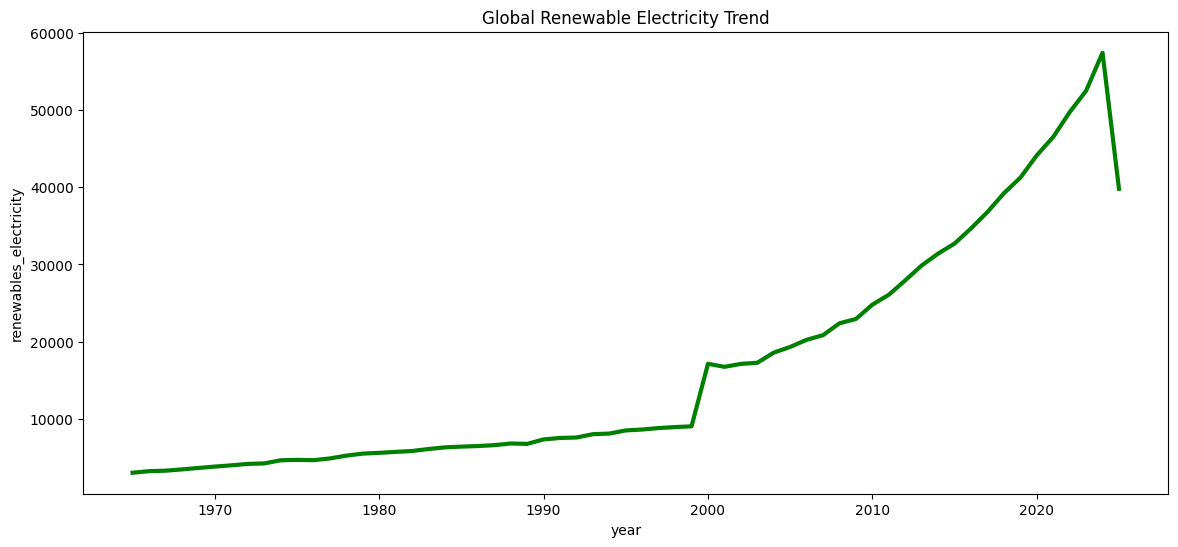

In [22]:
renew = (
    df.groupby('year')['renewables_electricity']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=renew,
    x='year',
    y='renewables_electricity',
    color='green',
    linewidth=3
)

plt.title("Global Renewable Electricity Trend")
plt.show()

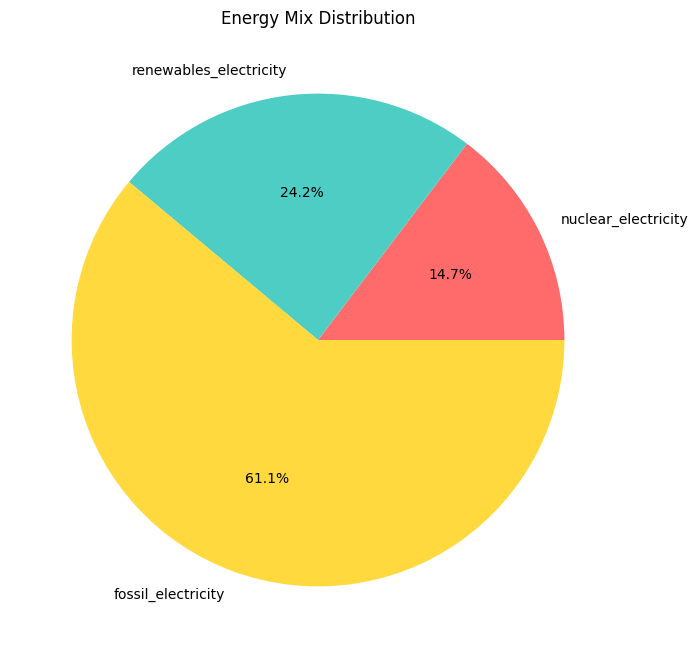

In [23]:
mix = df[[
    'nuclear_electricity',
    'renewables_electricity',
    'fossil_electricity'
]].sum()

plt.figure(figsize=(8,8))

colors = [
    '#FF6B6B',
    '#4ECDC4',
    '#FFD93D'
]

plt.pie(
    mix,
    labels=mix.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Energy Mix Distribution")
plt.show()


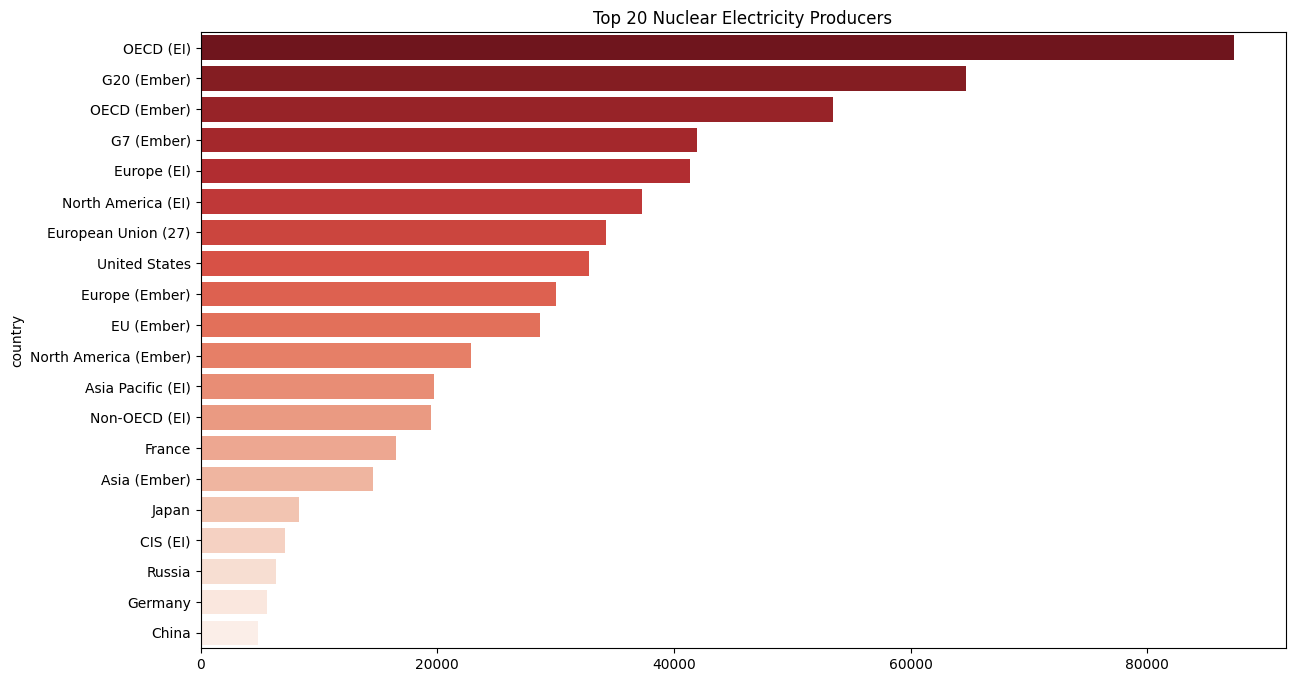

In [24]:
top_nuclear = (
    df.groupby('country')['nuclear_electricity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_nuclear.values,
    y=top_nuclear.index,
    palette='Reds_r'
)

plt.title("Top 20 Nuclear Electricity Producers")
plt.show()

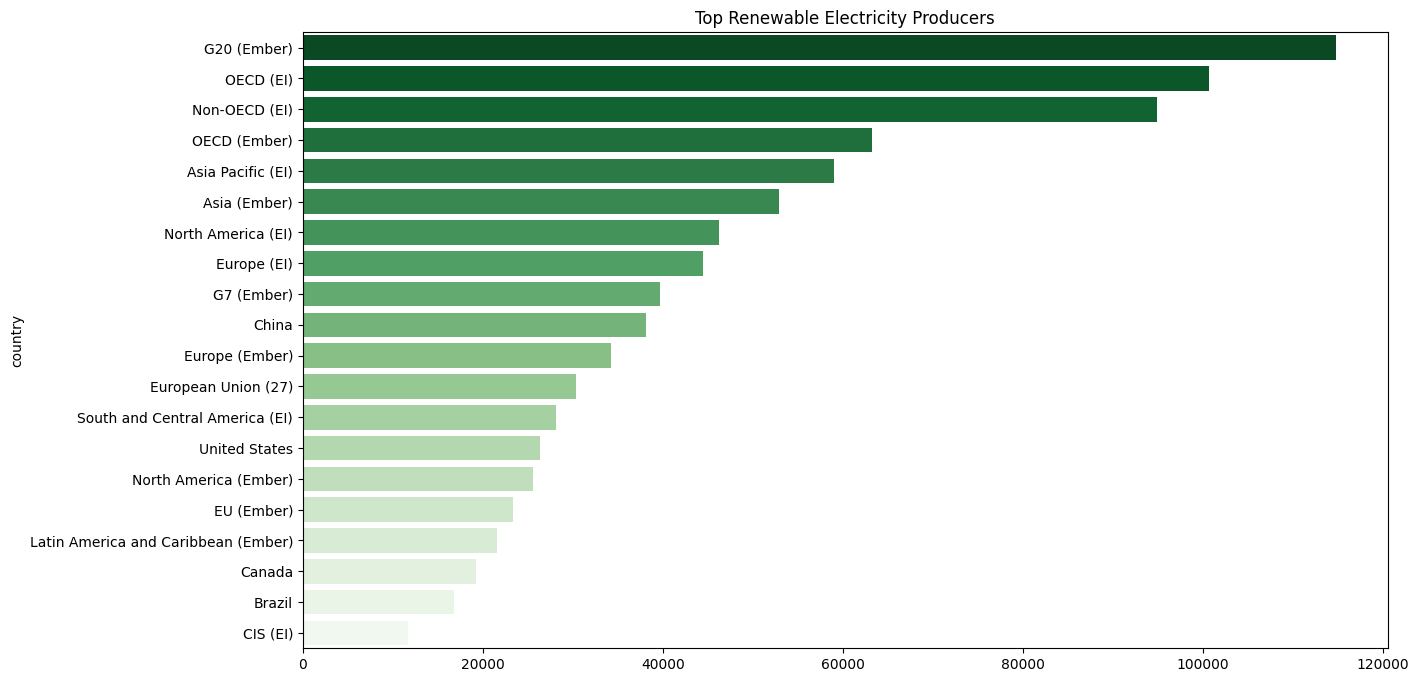

In [25]:
top_renew = (
    df.groupby('country')['renewables_electricity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=top_renew.values,
    y=top_renew.index,
    palette='Greens_r'
)

plt.title("Top Renewable Electricity Producers")
plt.show()

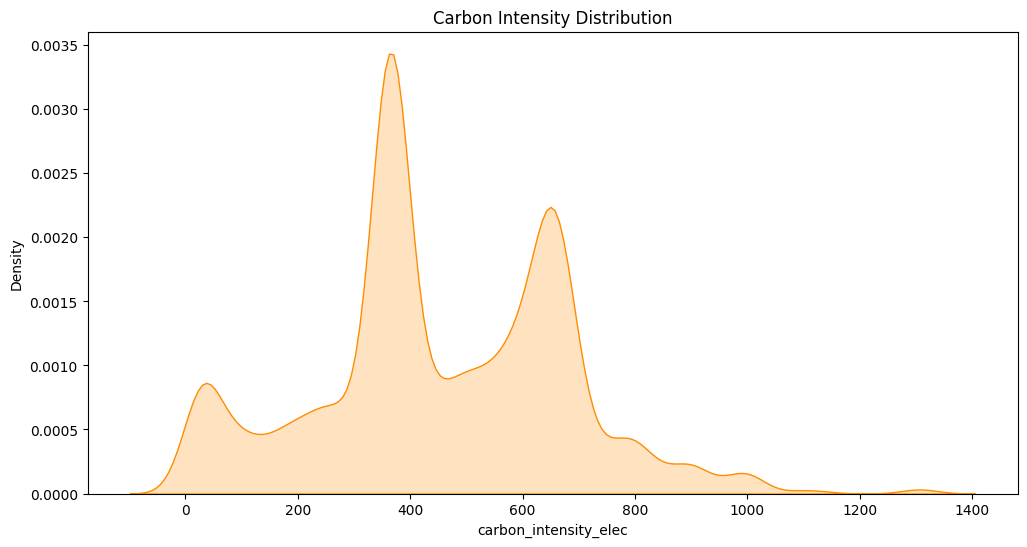

In [26]:
plt.figure(figsize=(12,6))

sns.kdeplot(
    df['carbon_intensity_elec'],
    fill=True,
    color='darkorange'
)

plt.title("Carbon Intensity Distribution")
plt.show()

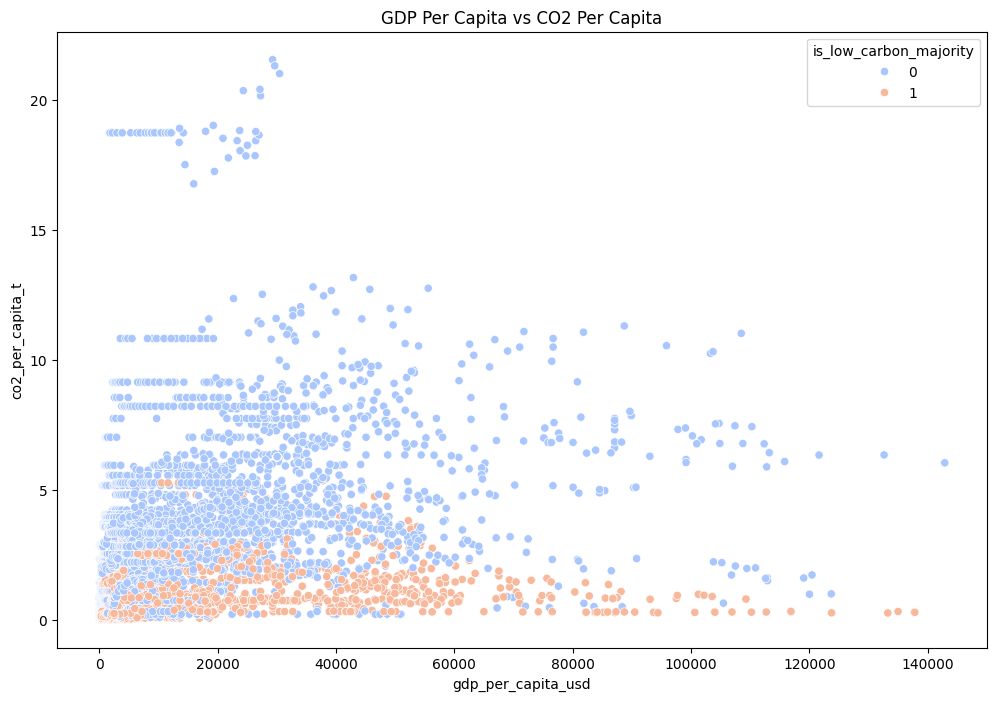

In [27]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='gdp_per_capita_usd',
    y='co2_per_capita_t',
    hue='is_low_carbon_majority',
    palette='coolwarm'
)

plt.title("GDP Per Capita vs CO2 Per Capita")
plt.show()

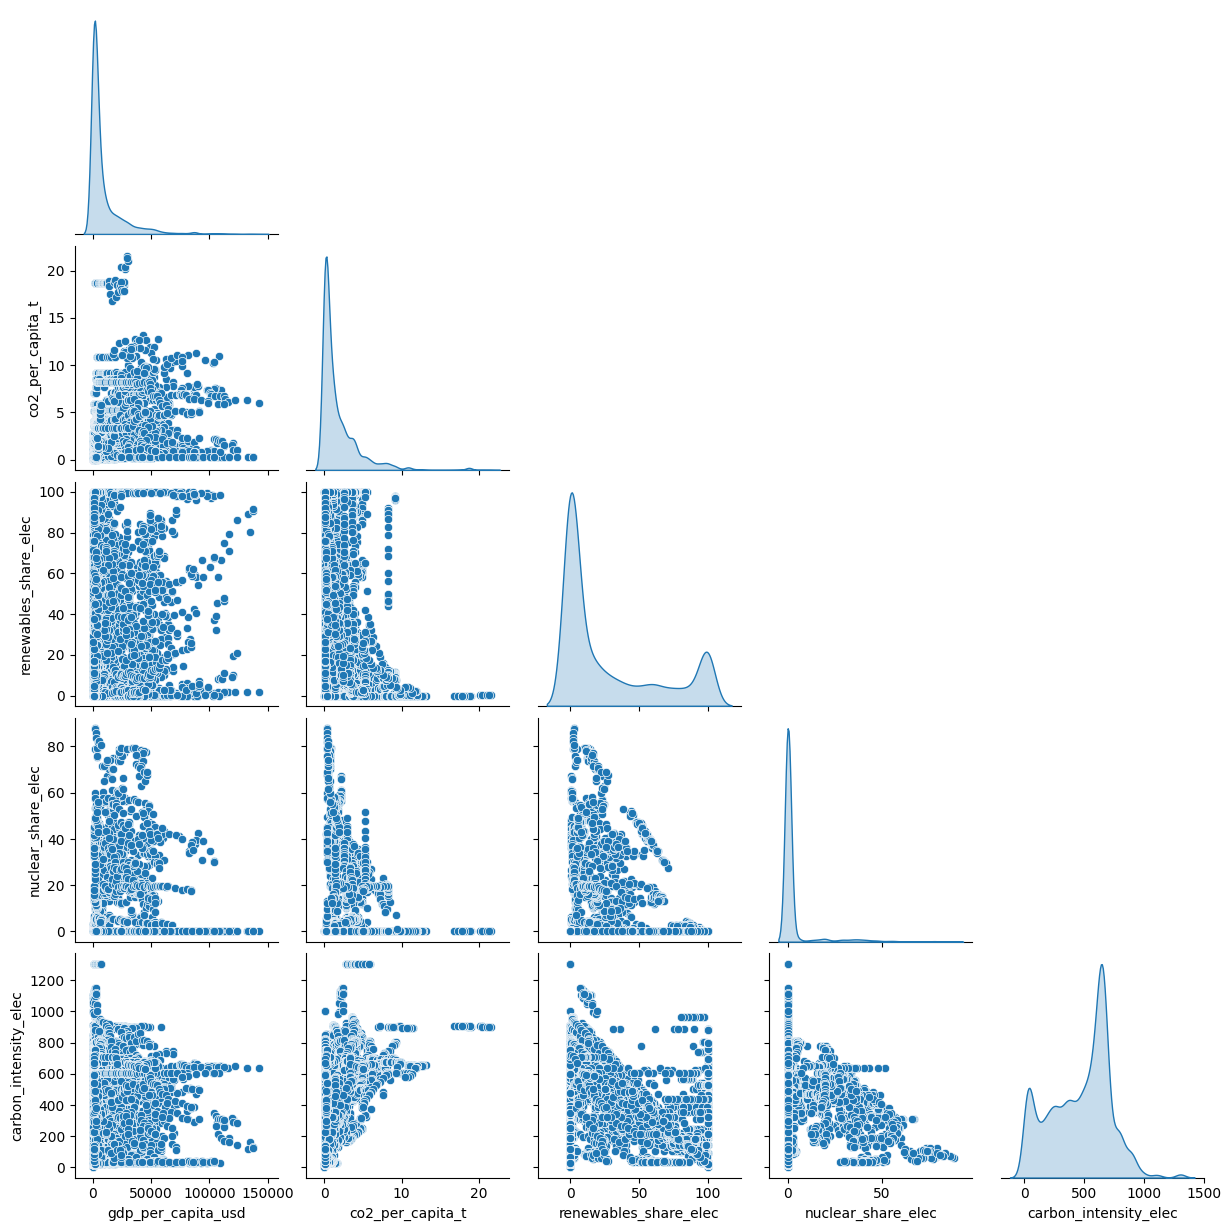

In [28]:
important_cols = [
    'gdp_per_capita_usd',
    'co2_per_capita_t',
    'renewables_share_elec',
    'nuclear_share_elec',
    'carbon_intensity_elec'
]

sns.pairplot(
    df[important_cols].dropna(),
    corner=True,
    diag_kind='kde'
)

plt.show()

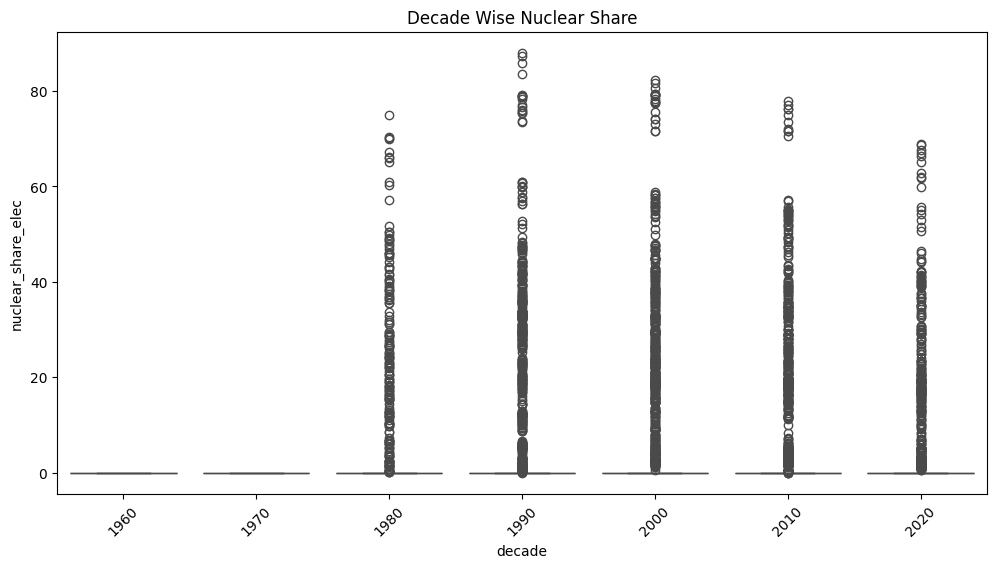

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='decade',
    y='nuclear_share_elec',
    palette='Spectral'
)

plt.xticks(rotation=45)
plt.title("Decade Wise Nuclear Share")
plt.show()

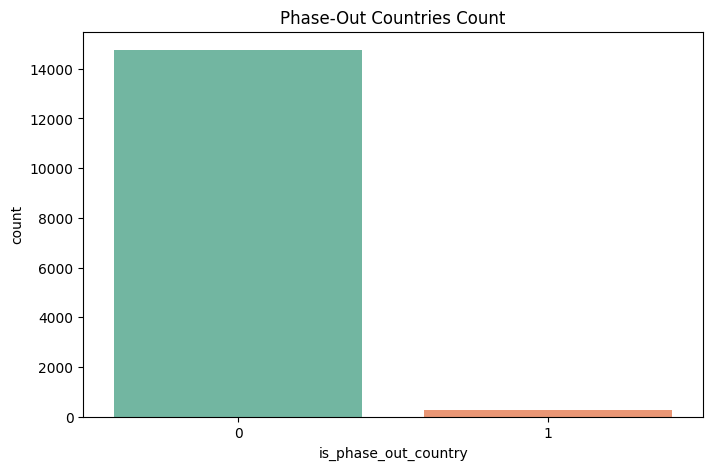

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='is_phase_out_country',
    palette='Set2'
)

plt.title("Phase-Out Countries Count")
plt.show()

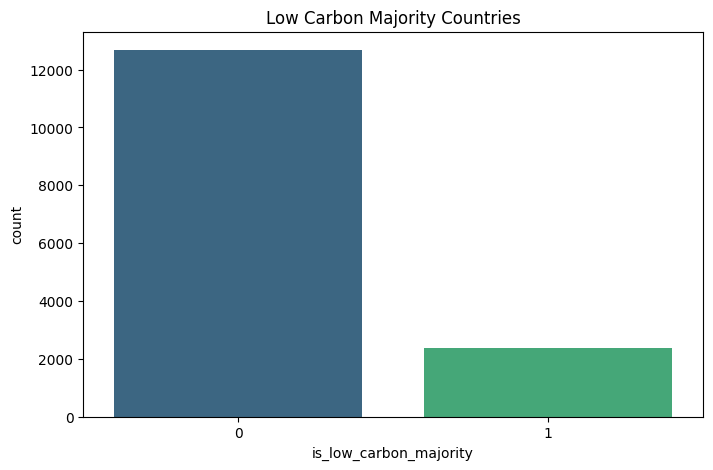

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='is_low_carbon_majority',
    palette='viridis'
)

plt.title("Low Carbon Majority Countries")
plt.show()

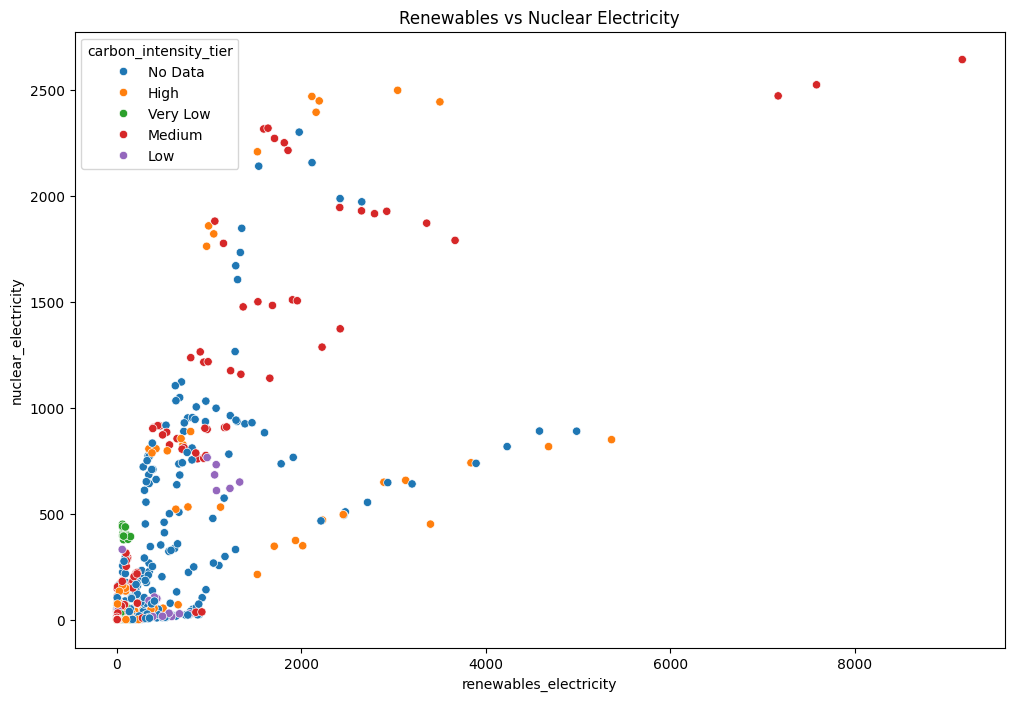

In [32]:
sample = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=sample,
    x='renewables_electricity',
    y='nuclear_electricity',
    hue='carbon_intensity_tier',
    palette='tab10'
)

plt.title("Renewables vs Nuclear Electricity")
plt.show()


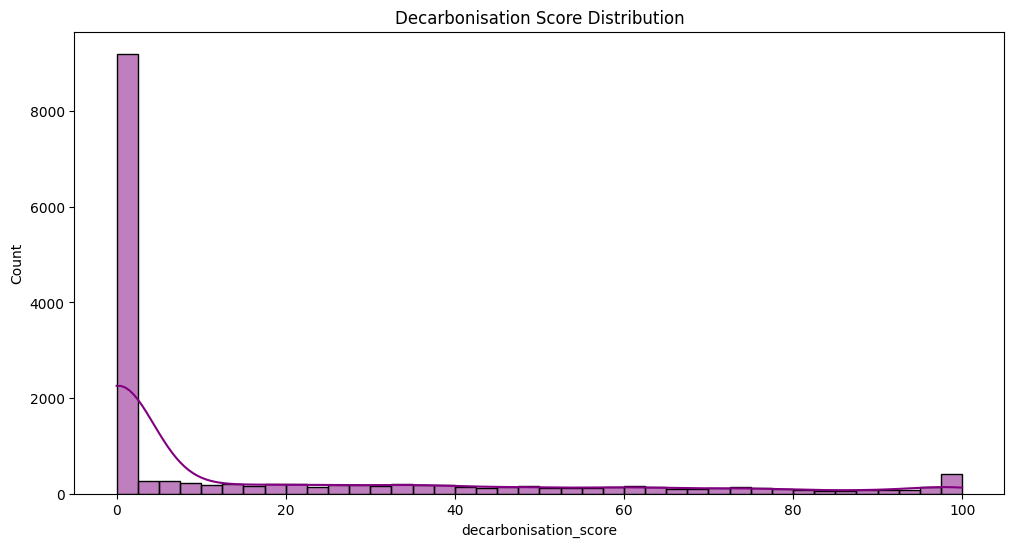

In [33]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['decarbonisation_score'],
    bins=40,
    kde=True,
    color='purple'
)

plt.title("Decarbonisation Score Distribution")
plt.show()


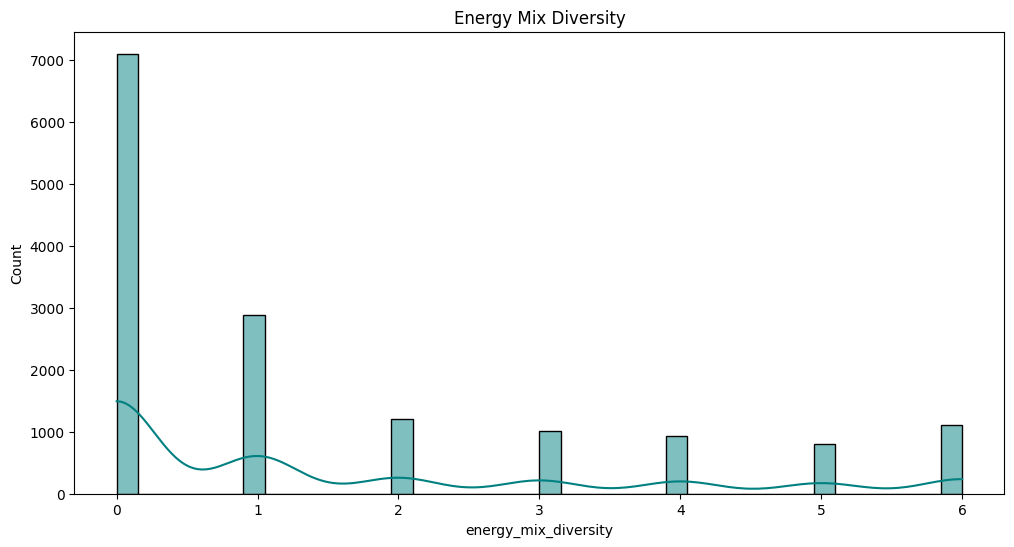

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['energy_mix_diversity'],
    bins=40,
    kde=True,
    color='teal'
)

plt.title("Energy Mix Diversity")
plt.show()


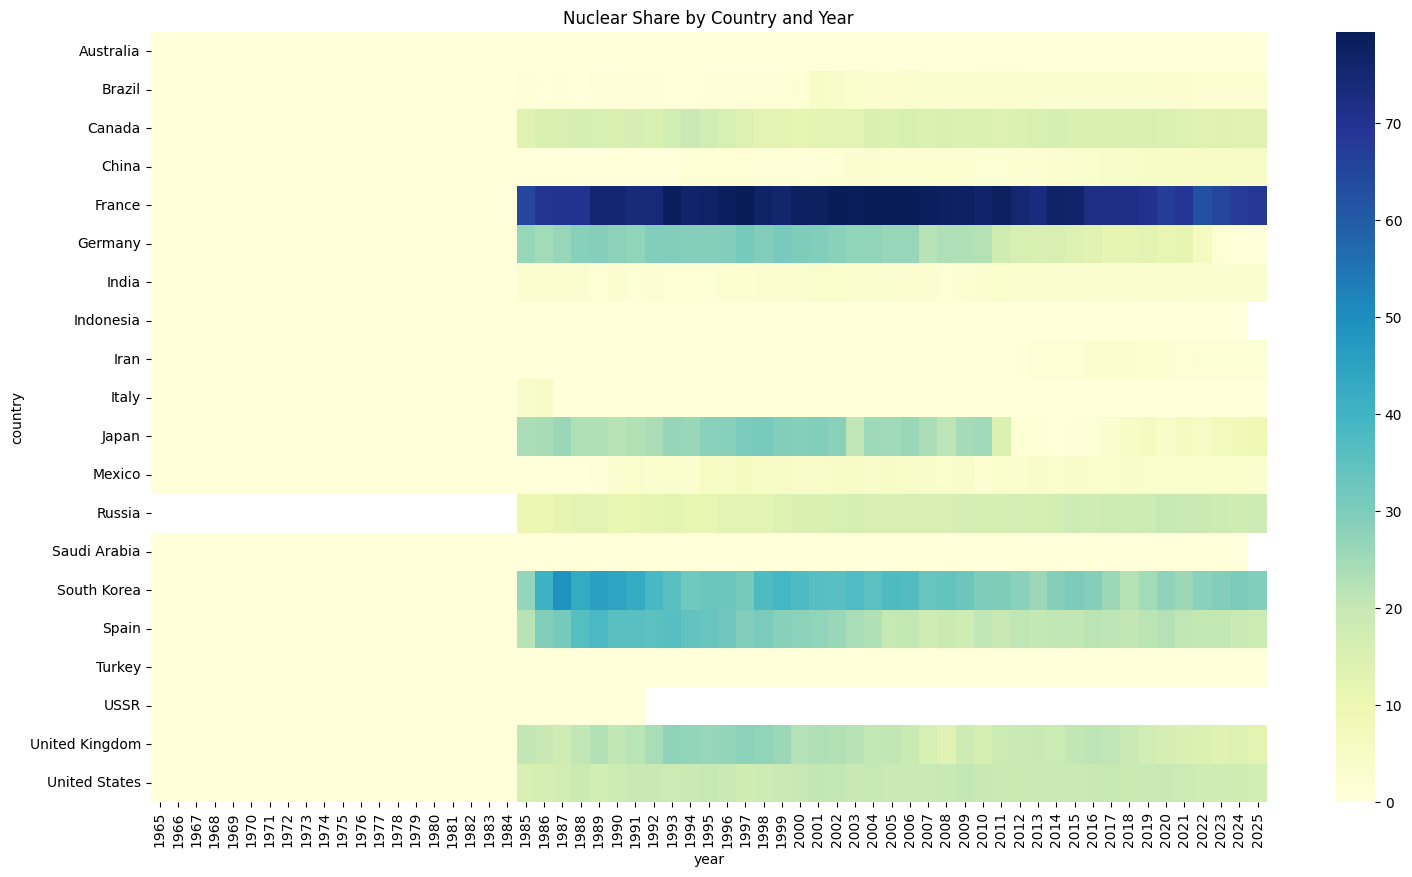

In [35]:
top_countries = (
    df.groupby('country')['gdp']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)

heat_data = df[
    df['country'].isin(top_countries)
].pivot_table(
    index='country',
    columns='year',
    values='nuclear_share_elec',
    aggfunc='mean'
)

plt.figure(figsize=(18,10))

sns.heatmap(
    heat_data,
    cmap='YlGnBu'
)

plt.title("Nuclear Share by Country and Year")
plt.show()

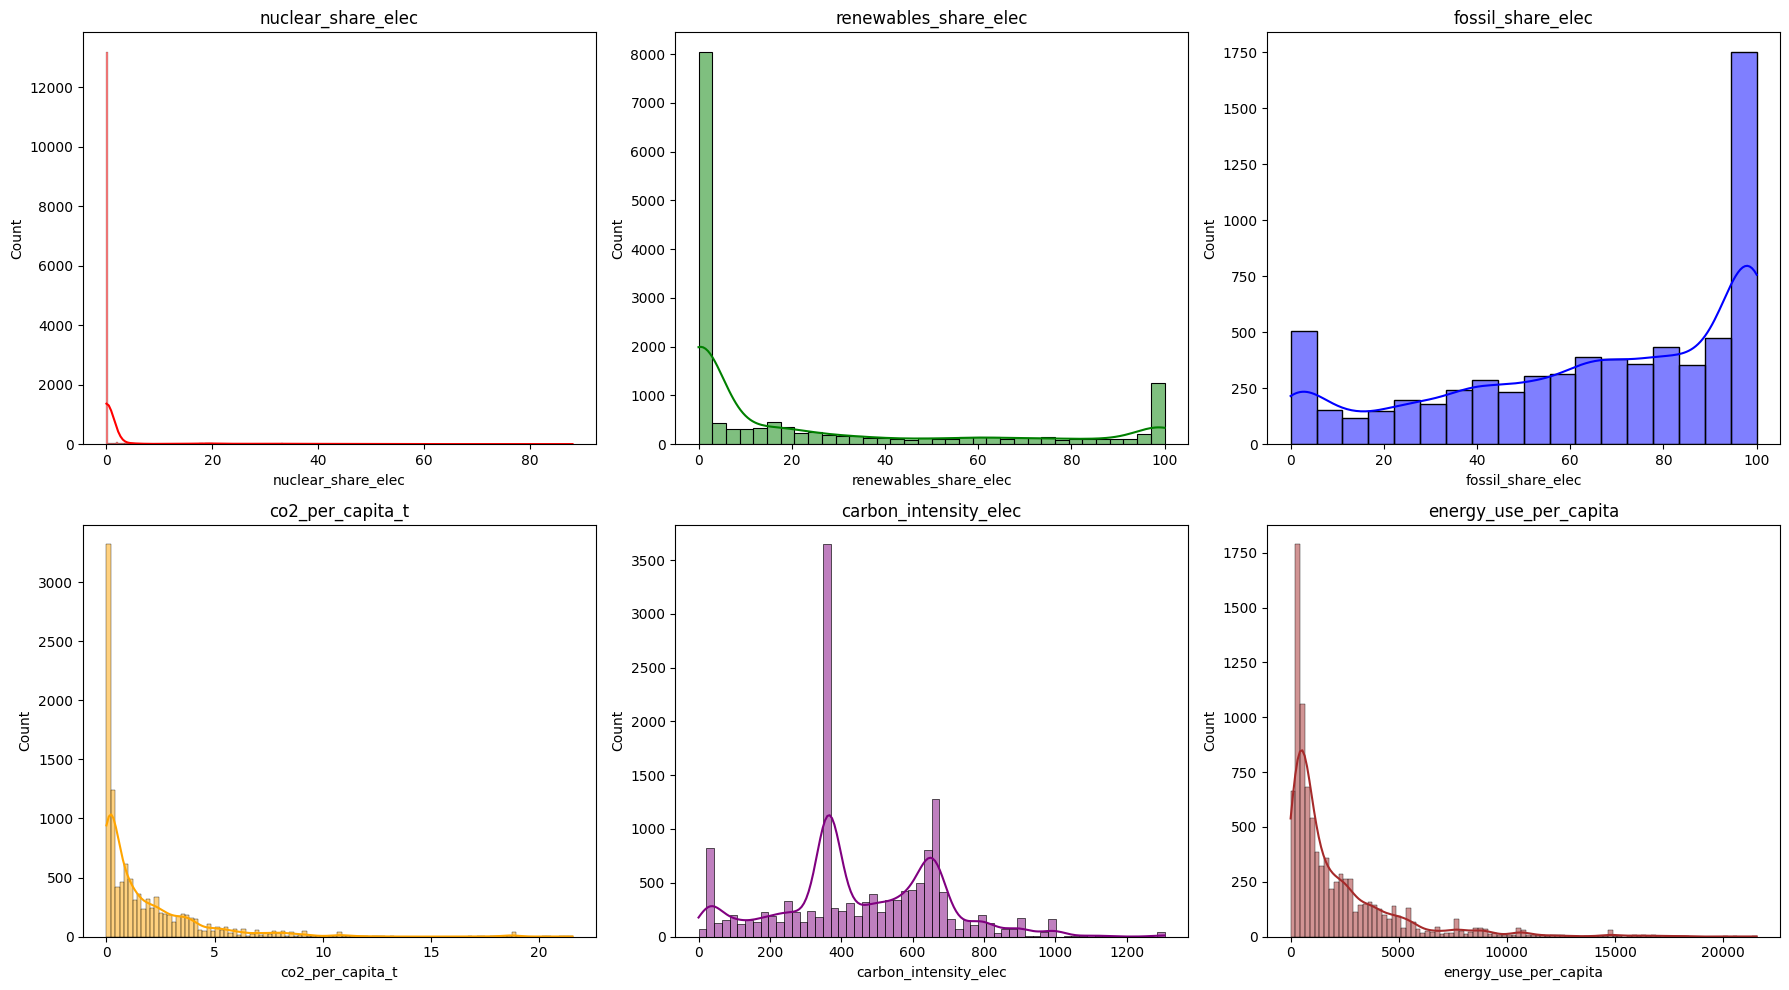

Visualization Completed Successfully


In [36]:
selected = [
    'nuclear_share_elec',
    'renewables_share_elec',
    'fossil_share_elec',
    'co2_per_capita_t',
    'carbon_intensity_elec',
    'energy_use_per_capita'
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

colors = [
    'red',
    'green',
    'blue',
    'orange',
    'purple',
    'brown'
]

for i, col in enumerate(selected):

    sns.histplot(
        df[col],
        kde=True,
        color=colors[i],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

print("Visualization Completed Successfully")

## Feature engineering

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [38]:
data = df.copy()

In [39]:
TARGET = "is_nuclear_active"

In [40]:
leakage_cols = [
    'last_nuclear_year'
]

existing_leakage = [
    c for c in leakage_cols
    if c in data.columns
]

data = data.drop(columns=existing_leakage)

In [41]:
data = data.dropna(subset=[TARGET])

In [42]:
le = LabelEncoder()

data[TARGET] = le.fit_transform(
    data[TARGET].astype(str)
)

In [43]:
X = data.drop(columns=[TARGET])
y = data[TARGET]

In [44]:
categorical_cols = X.select_dtypes(
    include=['object','category']
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64','float64']
).columns.tolist()

print("Numerical Features:", len(numerical_cols))
print("Categorical Features:", len(categorical_cols))

Numerical Features: 48
Categorical Features: 4


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Train Shape: (12036, 52)
Test Shape : (3009, 52)


In [46]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [47]:
models = {
    
    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "KNN":
    KNeighborsClassifier(
        n_neighbors=7
    ),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    )
}




Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



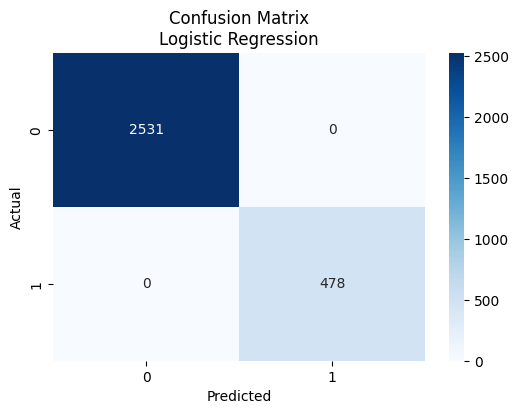



Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



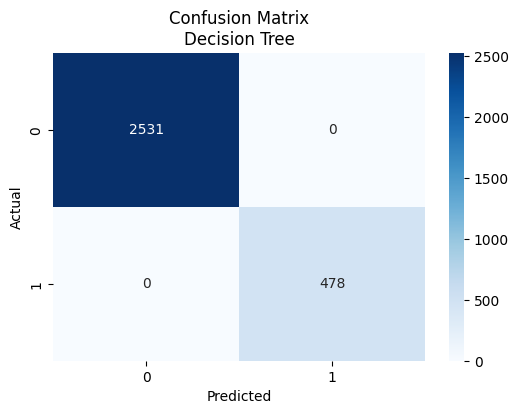



Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



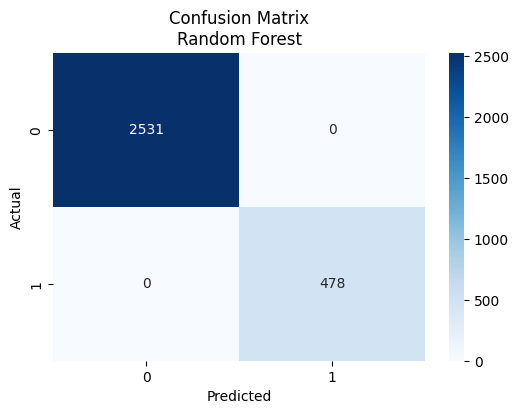



Extra Trees
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



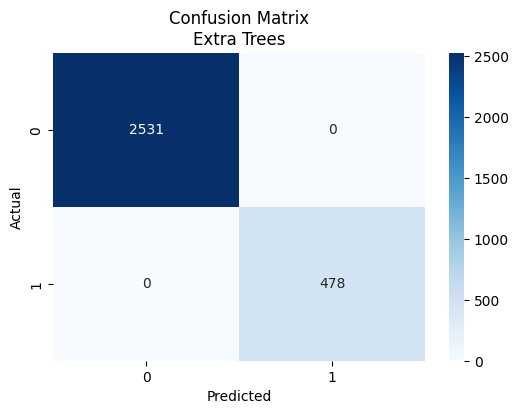



Gradient Boosting
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



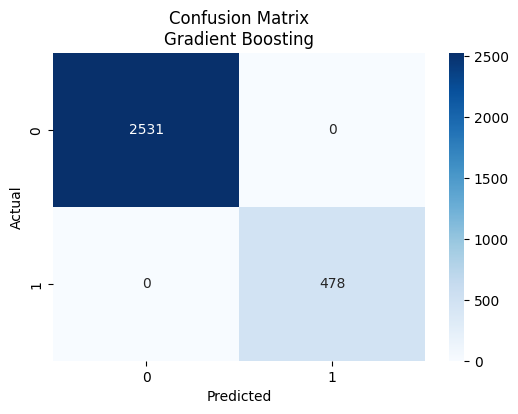



KNN
Accuracy : 0.999
Precision: 0.9979
Recall   : 0.9958
F1 Score : 0.9969
ROC AUC  : 0.9989

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



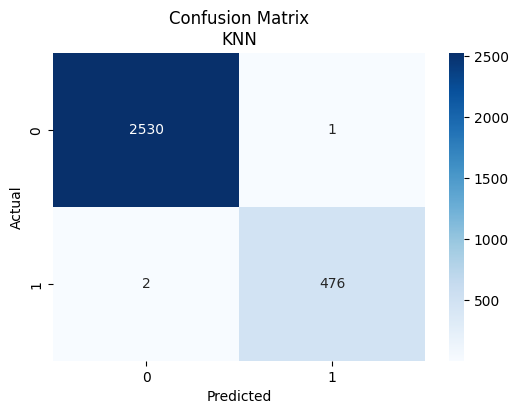



SVM
Accuracy : 0.9997
Precision: 0.9979
Recall   : 1.0
F1 Score : 0.999
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2531
           1       1.00      1.00      1.00       478

    accuracy                           1.00      3009
   macro avg       1.00      1.00      1.00      3009
weighted avg       1.00      1.00      1.00      3009



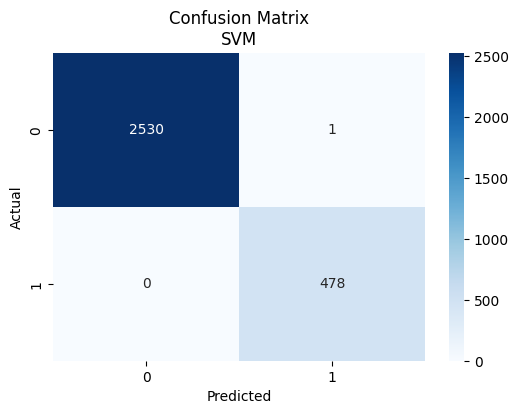



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000
1        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000
2        Random Forest  1.000000   1.000000  1.000000  1.000000  1.000000
3          Extra Trees  1.000000   1.000000  1.000000  1.000000  1.000000
4    Gradient Boosting  1.000000   1.000000  1.000000  1.000000  1.000000
6                  SVM  0.999668   0.997912  1.000000  0.998955  0.999998
5                  KNN  0.999003   0.997904  0.995816  0.996859  0.998939


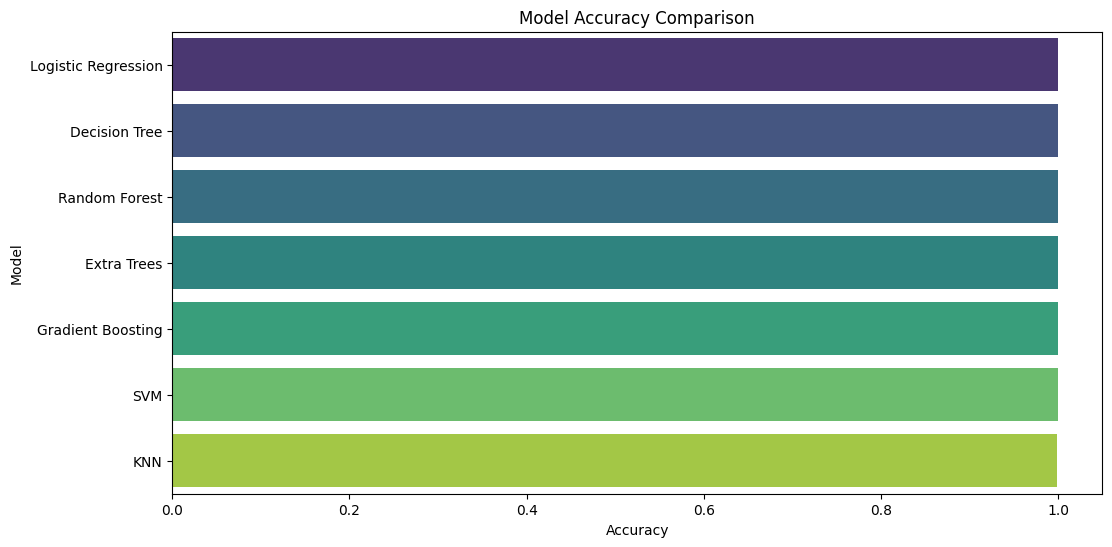

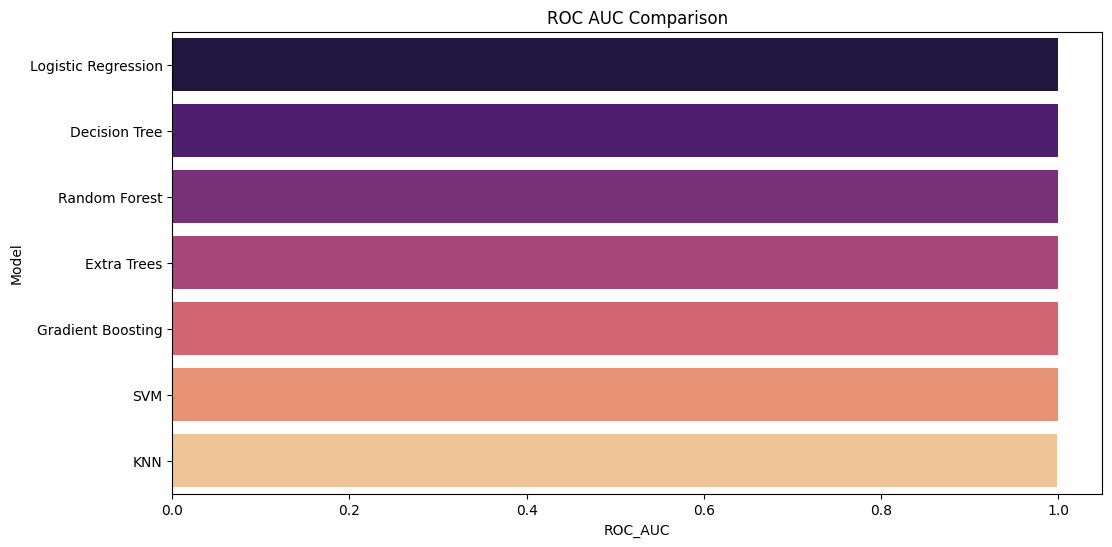

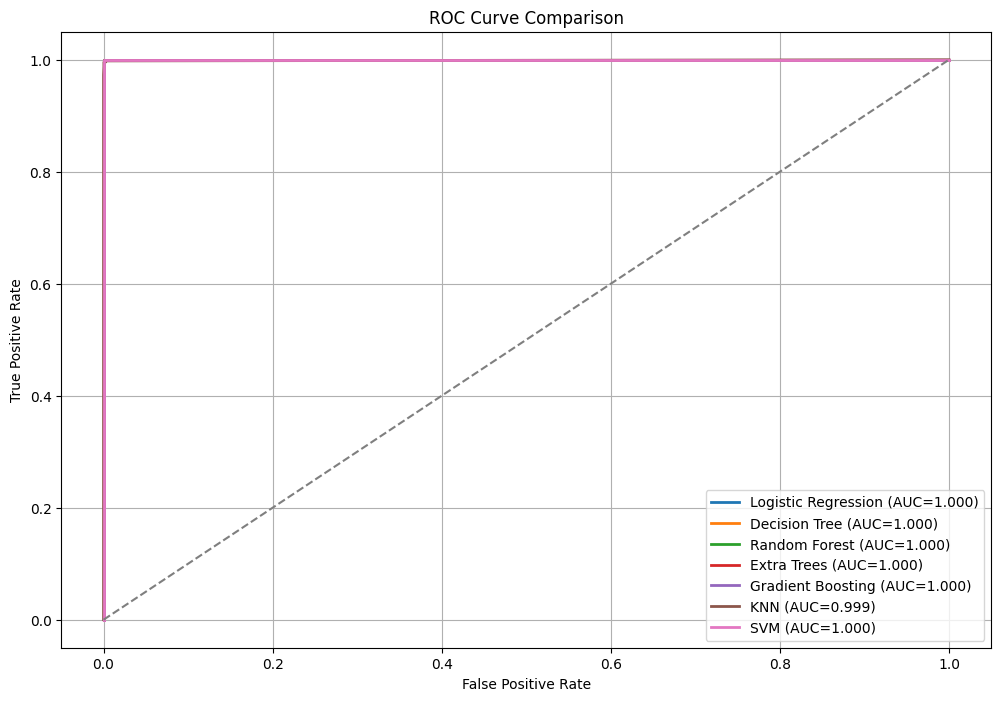


Best Model
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1                           1.0
ROC_AUC                      1.0
Name: 0, dtype: object

Pipeline Completed Successfully


In [48]:
results = []

roc_data = {}

for name, model in models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    roc_data[name] = (
        y_test,
        y_prob
    )

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # ==========================================
    # CONFUSION MATRIX
    # ==========================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f"Confusion Matrix\n{name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# BARPLOT OF ACCURACY
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.show()

# ==========================================================
# BARPLOT OF ROC AUC
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="ROC_AUC",
    y="Model",
    palette="magma"
)

plt.title("ROC AUC Comparison")
plt.show()

# ==========================================================
# ROC CURVES
# ==========================================================

plt.figure(figsize=(12,8))

for name, values in roc_data.items():

    yt, yp = values

    fpr, tpr, _ = roc_curve(
        yt,
        yp
    )

    auc_score = roc_auc_score(
        yt,
        yp
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\nBest Model")
print(best_model)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================
# For tree-based best models only

tree_models = [
    "Random Forest",
    "Extra Trees",
    "Decision Tree"
]

if best_model["Model"] in tree_models:

    print("\nTraining best model for feature importance...")

    best_estimator = models[
        best_model["Model"]
    ]

    pipe = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", best_estimator)
        ]
    )

    pipe.fit(X_train, y_train)

    feature_names = pipe.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importances = pipe.named_steps[
        "model"
    ].feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(25)

    plt.figure(figsize=(12,8))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette="rocket"
    )

    plt.title(
        f"Top Features ({best_model['Model']})"
    )

    plt.show()

print("\nPipeline Completed Successfully")

## Thanl you....pls upvote!!!!!!!!!!!!!!!